# SPKIR CG data deep dive 1.2

In this notebook we display OOI SPKIR data stored in the kdata drive for certain deployments that may need additional annotations. Ref Des: CP03ISSM-RID26-08-SPKIRB000

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import norm

from ooi_data_explorations.common import list_methods, list_streams, get_annotations, add_annotation_qc_flags, load_kdata, get_vocabulary, update_dataset
from ooi_data_explorations.uncabled.process_spkir import spkir_datalogger
from ooinet.M2M import get_deployments
from qartod_testing.data_deep_dive import nanfill_time_gaps, check_chla_swr

In [2]:
# Set parameters for data request 
refdes = 'CP03ISSM-RID26-08-SPKIRB000'
site, node, sensor = refdes.split('-', 2)

In [3]:
# Set parameter for comparison of SPKIR with FLORT Chl-a estimate
flort_node = 'RID27'

### Check data delivery method, deployments, and annotations

In [4]:
# Create dict of methods and associated data streams
methods = list_methods(site, node, sensor)

streams = {}
for method in methods:
    streams[method] = list_streams(site, node, sensor, method)

streams

{'recovered_host': ['spkir_abj_dcl_instrument_recovered'],
 'telemetered': ['spkir_abj_dcl_instrument']}

In [5]:
# View deployment information
deployments = get_deployments(refdes)
deployments

,deploymentNumber,uid,assetId,latitude,longitude,depth,deployStart,deployEnd,deployCruise,recoverCruise
0,1,CGINS-SPKIRB-00270,1474,40.3619,-70.878,7.0,2014-12-14 18:53:00,2014-12-28 16:30:00,KN224,AT31
1,2,CGINS-SPKIRB-00273,1472,40.35945,-70.88528,7.0,2015-05-09 00:57:00,2015-10-21 18:50:00,AT27,AT31
2,3,CGINS-SPKIRB-00290,1409,40.36472,-70.88837,7.0,2015-10-21 17:44:00,2016-05-14 13:45:00,AT31,AR4
3,4,CGINS-SPKIRB-00301,1944,40.35945,-70.88498,7.0,2016-05-28 14:43:00,2016-10-15 12:14:00,AR4,AR8
4,5,CGINS-SPKIRB-00290,1409,40.36192,-70.87827,7.0,2016-10-11 13:39:00,2017-06-15 15:56:00,AR8,AR18
5,6,CGINS-SPKIRB-00274,1483,40.367067,-70.881617,7.0,2017-06-15 13:43:00,2017-11-01 14:17:00,AR18,AR24
6,7,CGINS-SPKIRB-00238,2545,40.358983,-70.885467,7.0,2017-11-01 12:22:00,2018-03-28 16:56:00,AR24,AR28
7,8,CGINS-SPKIRB-00269,1441,40.36718,-70.88215,7.0,2018-03-25 15:27:00,2018-10-26 19:52:00,AR28,AR31
8,9,CGINS-SPKIRB-00270,1474,40.36728,-70.88105,7.0,2018-10-29 03:43:00,2019-04-06 18:51:00,AR31,AR34
9,10,CGINS-SPKIRB-00229,2512,40.36723,-70.88147,7.0,2019-04-07 14:42:00,2019-10-01 11:58:00,AR34,AR39


In [6]:
## View annotations
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)

if not annotations.empty:
    annotations = annotations.drop(columns=['@class'])
    annotations['beginDate'] = pd.to_datetime(annotations.beginDT, unit='ms').dt.strftime('%Y-%m-%dT%H:%M:%S')
    annotations['endDate'] = pd.to_datetime(annotations.endDT, unit='ms').dt.strftime('%Y-%m-%dT%H:%M:%S')

annotations
# annotations['annotation'][5]

# Note: now I have moved the lines that add a human-readable date time up here where the annotations are displayed, however I'm not sure if the begin and endDT columns still need 
# to exist. I would like to remove them because they are just taking up space and don't add anything to the dataFrame displayed below.

,id,subsite,node,sensor,method,stream,beginDT,endDT,annotation,exclusionFlag,source,qcFlag,parameters,beginDate,endDate
0,2865,CP03ISSM,RID26,08-SPKIRB000,None,None,1604172660000,1617217320000,Deploylment 12: The UV light LED module failed...,False,swhite@whoi.edu,suspect,[],2020-10-31T19:31:00,2021-03-31T19:02:00
1,1510,CP03ISSM,RID26,None,telemetered,None,1529265880000,1540583520000,Data telemetry disabled due to chronic issues ...,False,leila@marine.rutgers.edu,None,[],2018-06-17T20:04:40,2018-10-26T19:52:00
2,1889,CP03ISSM,None,None,None,None,1578441600000,1604236560000,Deployment 11: UPDATED 2020-04-27: As of 2020-...,False,cdobson@whoi.edu,not_operational,[],2020-01-08T00:00:00,2020-11-01T13:16:00
3,2946,CP03ISSM,RID26,None,None,None,1628089200000,1630411200000,Deployment 13: * UPDATED 2021-09-11: NSIF powe...,False,cdobson@whoi.edu,not_operational,[],2021-08-04T15:00:00,2021-08-31T12:00:00
4,3264,CP03ISSM,RID26,None,None,None,1633176000000,1633939200000,Deployment 13: A gap exists in the telemetered...,False,cdobson@whoi.edu,None,[],2021-10-02T12:00:00,2021-10-11T08:00:00
5,3379,CP03ISSM,RID26,08-SPKIRB000,None,None,1628089200000,1636659000000,Deployment 13: On recovery biofouling was obse...,False,cdobson@whoi.edu,None,[],2021-08-04T15:00:00,2021-11-11T19:30:00
6,1774,CP03ISSM,RID26,08-SPKIRB000,None,None,1569505800000,1668347700000,The use of UV lamps has been implemented for b...,False,swhite@whoi.edu,None,[],2019-09-26T13:50:00,2022-11-13T13:55:00
7,5177,CP03ISSM,RID26,08-SPKIRB000,None,None,1442620800000,1443056400000,Deployment 2: No data available for the specif...,False,areed@whoi.edu,not_operational,[],2015-09-19T00:00:00,2015-09-24T01:00:00
8,5176,CP03ISSM,RID26,08-SPKIRB000,None,None,1435204800000,1439488800000,Deployment 2: No data available for the specif...,False,areed@whoi.edu,not_operational,[],2015-06-25T04:00:00,2015-08-13T18:00:00
9,5178,CP03ISSM,RID26,08-SPKIRB000,None,None,1502841600000,1504105200000,Deployment 6: No data available for the specif...,False,areed@whoi.edu,not_operational,[],2017-08-16T00:00:00,2017-08-30T15:00:00


In [8]:
annotations['annotation'][9]

'Deployment 6: No data available for the specified time period.'

### Deployment 1

Nothing seemingly wrong with the data that is available.

In [11]:
# Set method and stream strings
method = methods[1]
stream = streams[method][0]
deploy = 1

In [12]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


In [13]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [14]:
spkir = nanfill_time_gaps(spkir)

In [15]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 1206, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2014-12-14T19:00:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 15.0 15.0 ... 14.5
    input_voltage                  (station, time) float32 8.4 8.4 ... 8.43 8.4
    deployment                     (station, time) float32 1.0 1.0 ... 1.0 1.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.31
    raw_irradiance_412             (station, time) float32 2.161e+09 ... 2.15...
    raw_irradiance_444             (station, time) float32 2.178e+09 ... 2.15...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 0.4186 ... 0.116
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.36
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  telemetered
    stream:                             spkir_abj_dcl_instrument
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

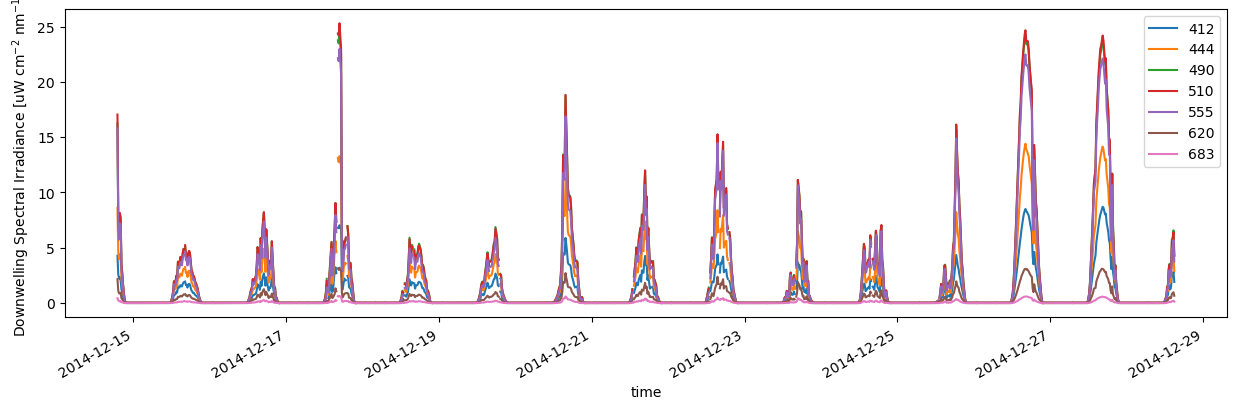

In [16]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

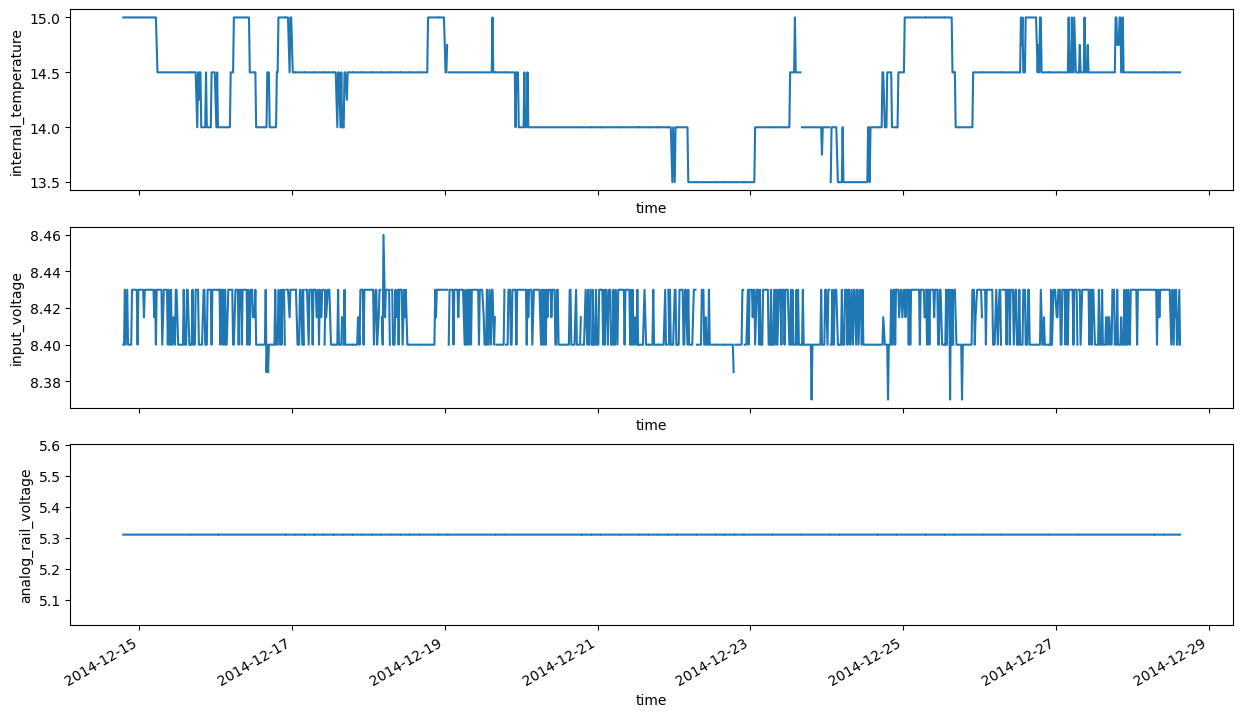

In [17]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

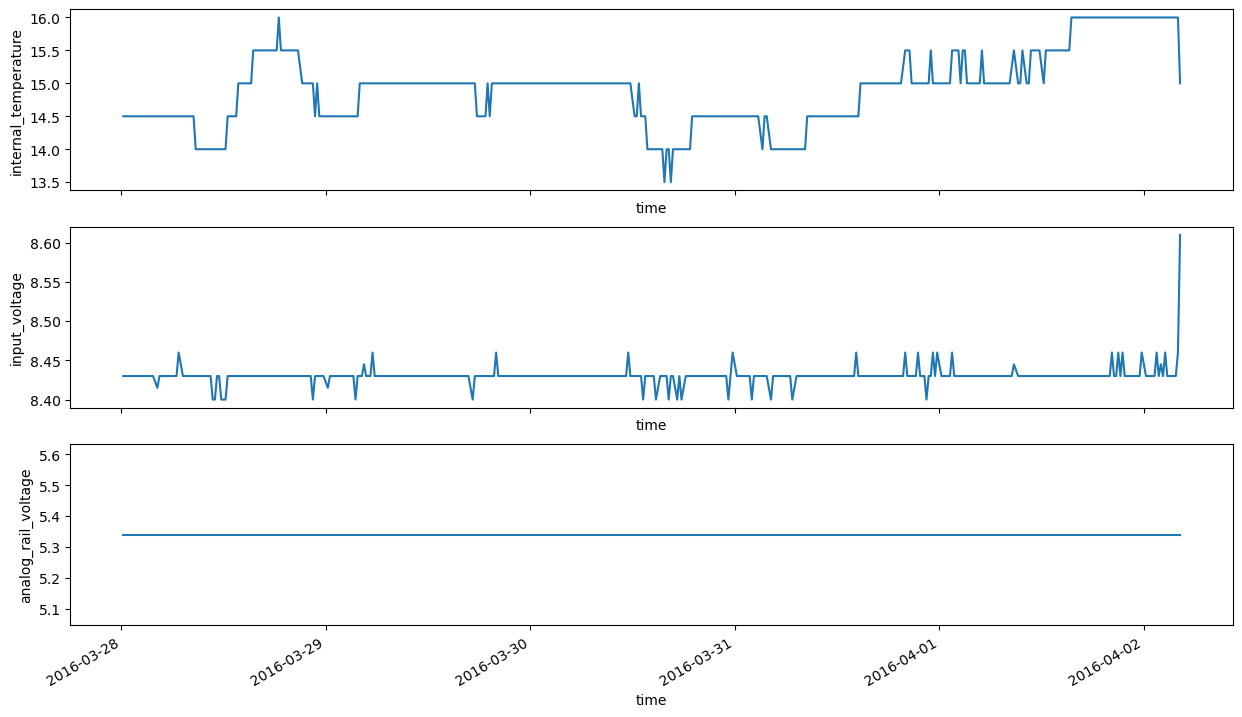

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

### Deployment 2

Since we don't already have an explanation for the data gap, I don't think we can provide one now. The available data looks fine.

In [41]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 2

In [42]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 3/3 [00:18<00:00,  6.23s/it]


In [43]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [44]:
spkir = nanfill_time_gaps(spkir)

In [45]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 8581, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2015-05-09T01:00:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 11.5 11.0 ... 25.5
    input_voltage                  (station, time) float32 8.37 8.37 ... 8.43
    deployment                     (station, time) float32 2.0 2.0 ... 2.0 2.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.31
    raw_irradiance_412             (station, time) float32 2.147e+09 ... 2.24...
    raw_irradiance_444             (station, time) float32 2.147e+09 ... 2.26...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 -0.004966 ... 0.9434
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.36
    lon                            (station) float32 -70.89
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

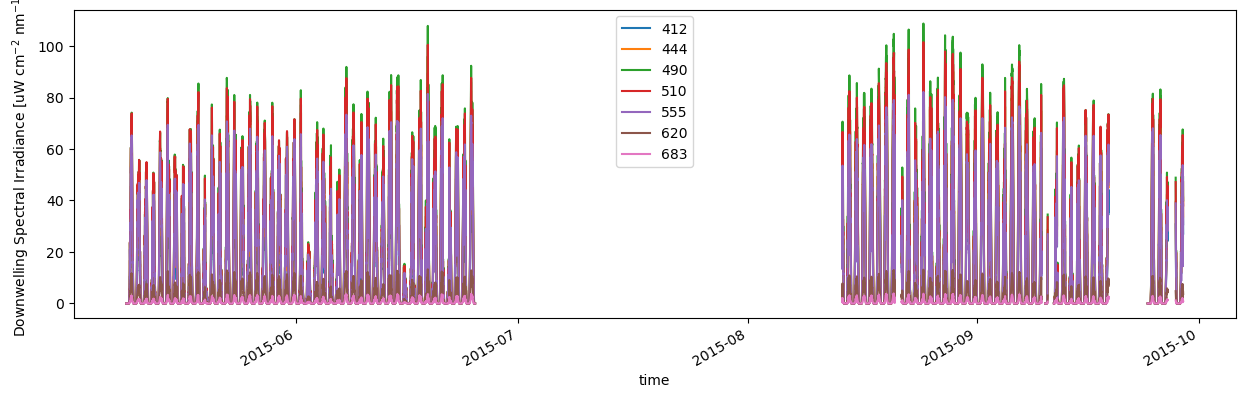

In [46]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

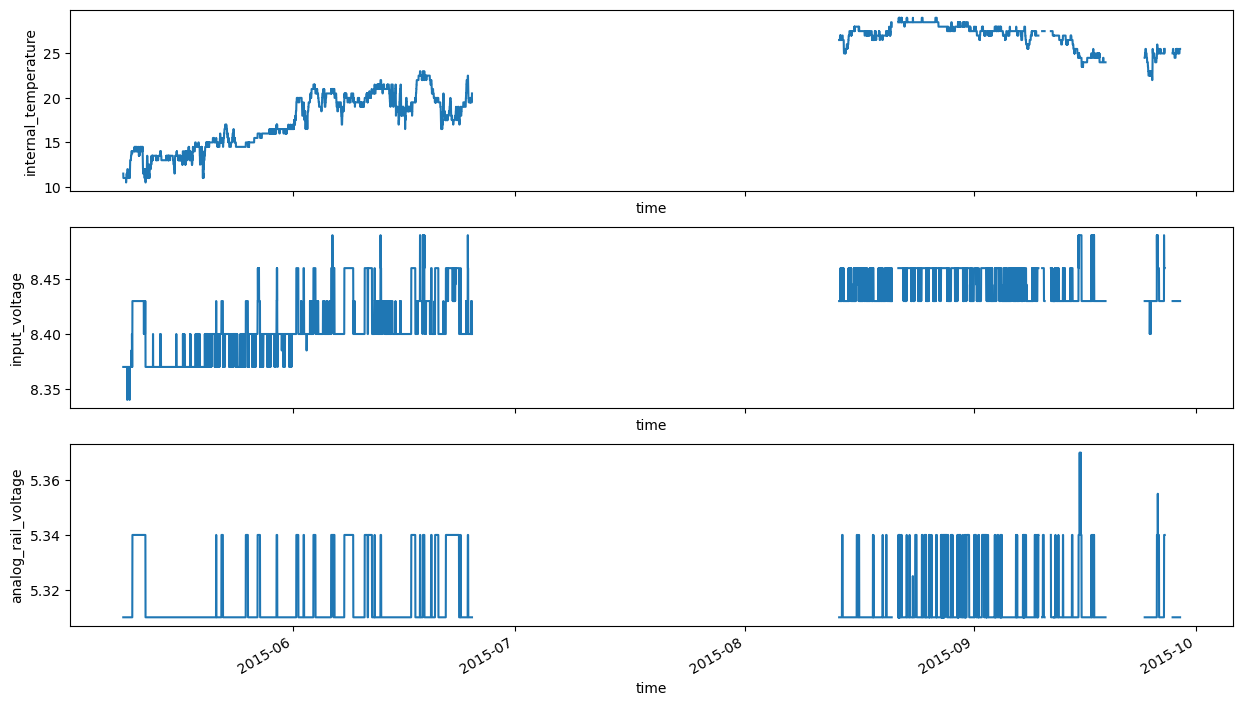

In [47]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

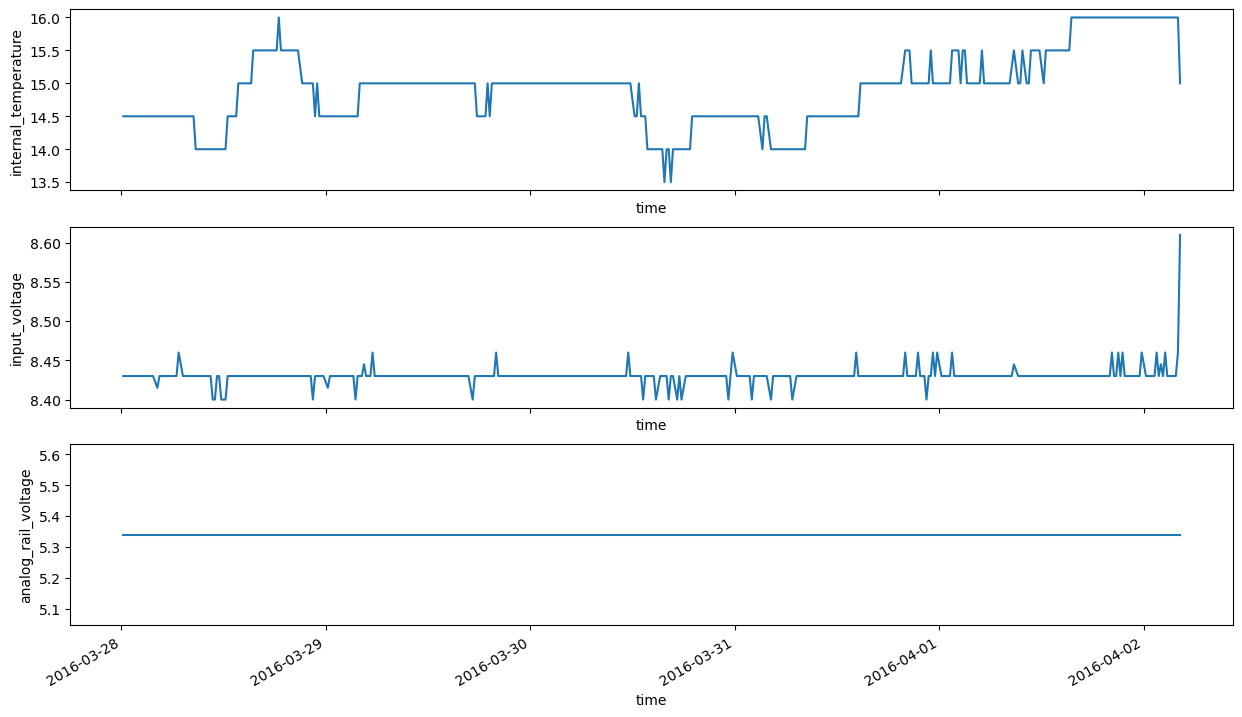

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

### Deployment 5

Toward the end of the deployment, the downwelling irradiance in every channel except the band centered on 444 nm drops toward zero.

Initially I suspected some biofouling could have played a role in this uncharacteristic change. After comparing the timing of this change from Chl-a estimates from the co-located FLORT and SWR from the surface buoy METBK suite, there seems to be a brief plankton bloom at the onset of the change, but after this the downwelling shortwave radiation above the surface does not decrease appreciably. I think it's reasonable to continue to suspect biofouling has some impact on the attenuation at the end of this record.

In [9]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 5

In [10]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.25s/it]


In [11]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [12]:
spkir = nanfill_time_gaps(spkir)

In [13]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 20322, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2016-10-11T13:45:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 25.5 25.5 ... 18.0
    input_voltage                  (station, time) float32 8.46 8.46 ... 8.4
    deployment                     (station, time) float32 5.0 5.0 ... 5.0 5.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.31
    raw_irradiance_412             (station, time) float32 2.174e+09 ... 2.15...
    raw_irradiance_444             (station, time) float32 2.179e+09 ... 2.18...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 0.1385 ... 0.7966
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.36
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

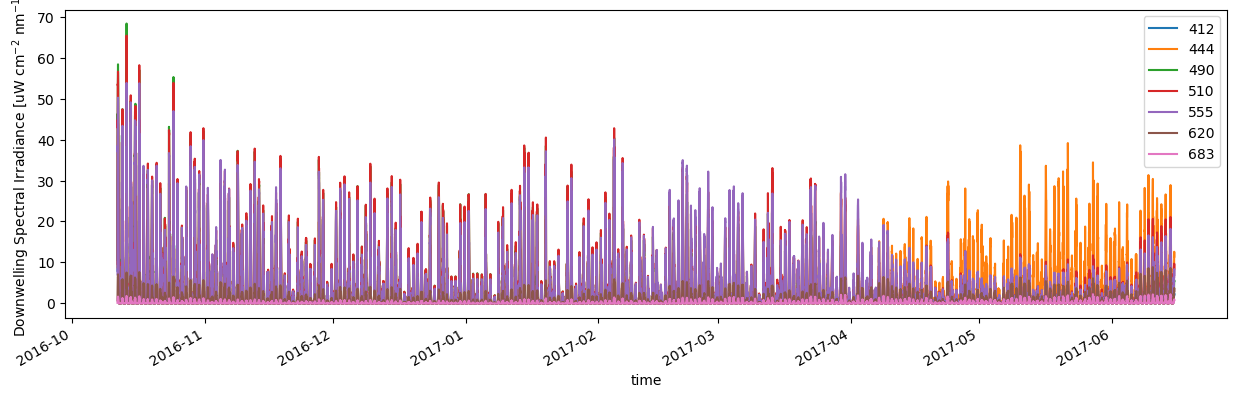

In [14]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

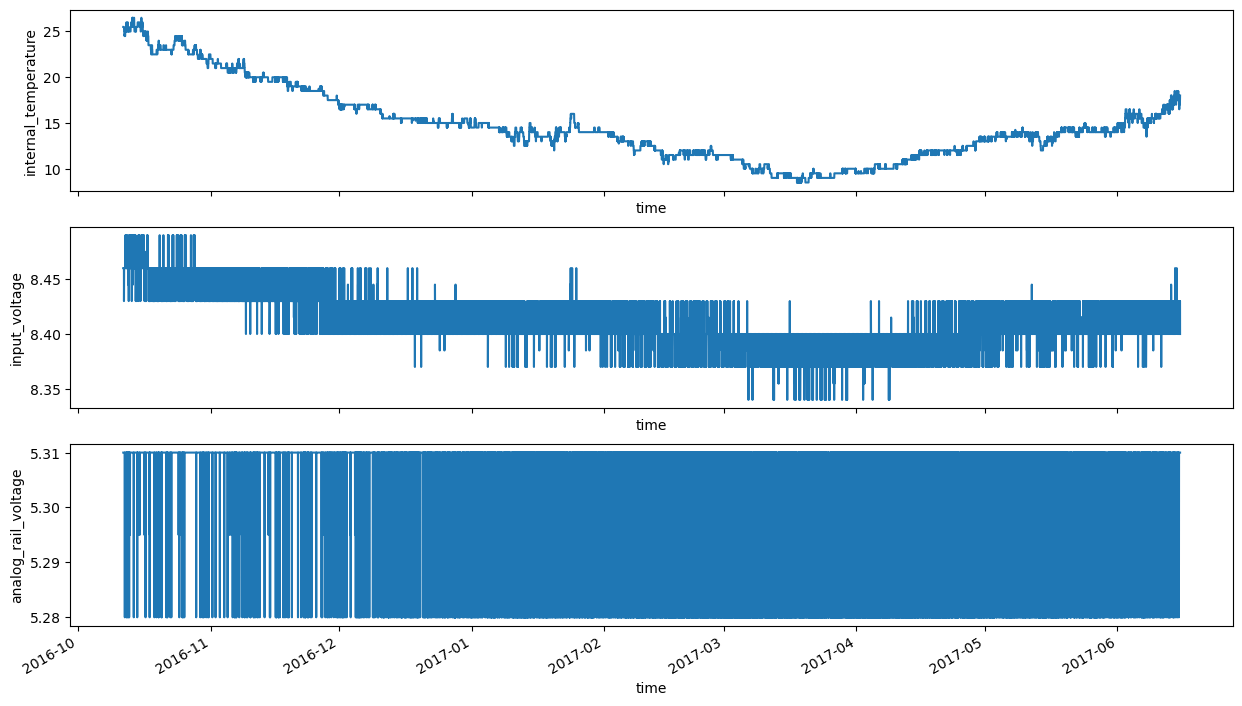

In [54]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

In [ ]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

Loading and Processing Data Files: 100%|██████████| 1/1 [00:02<00:00,  2.29s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.73s/it]


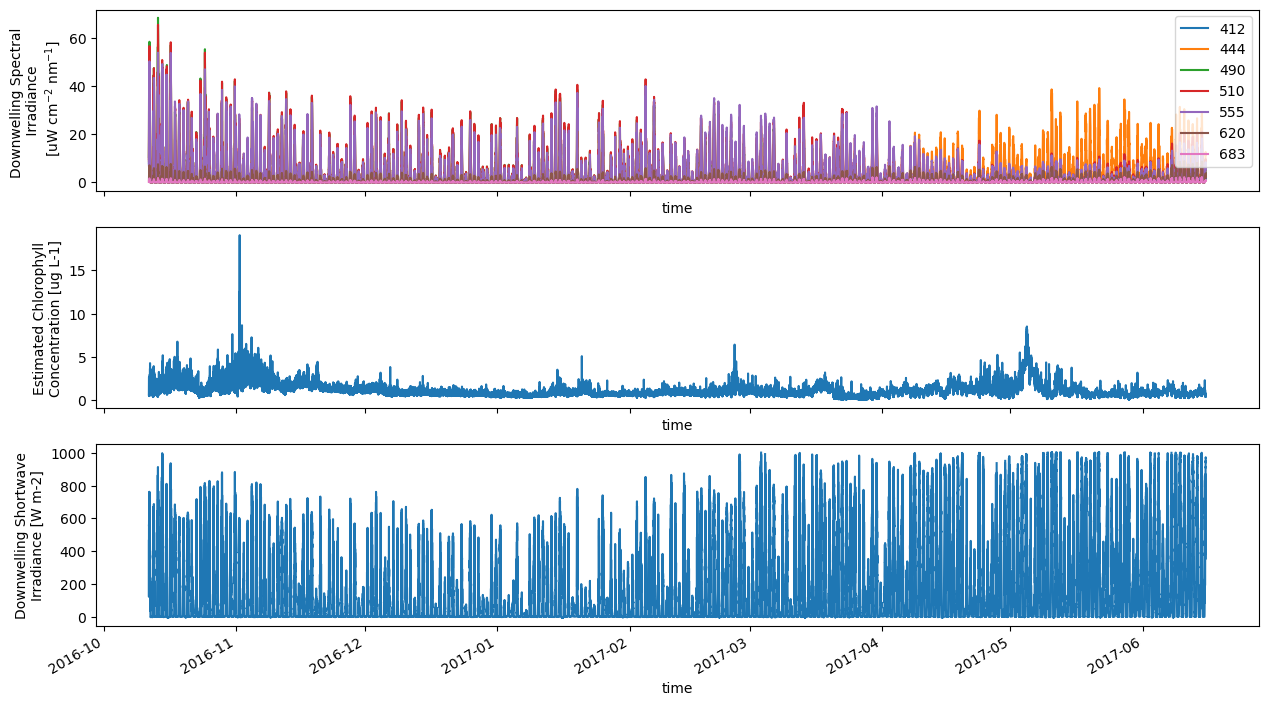

In [14]:
# Check behavior of shortwave irradiance and Chl-a during deployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, deploy, flort_node)

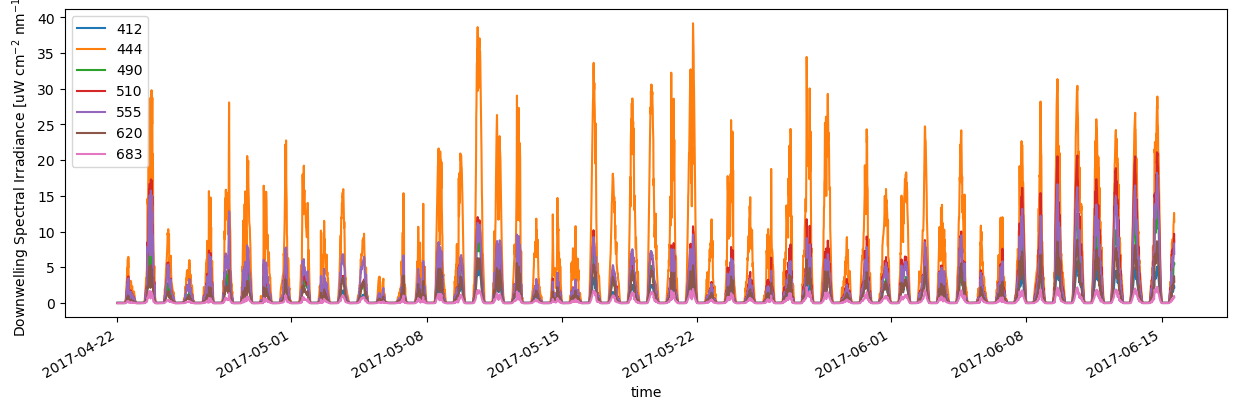

In [16]:
# Plot shorter time series after decrease in all channels except 444 nm
# to look for best start date for annotation.
spkir_end = spkir.sel(time=slice("04-22-2017","06-15-2017"))
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir_end.variables:
    if "downwelling_irradiance" in var:
        spkir_end[var].plot(ax=ax, label=spkir_end[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

It looks like the 444 nm channel first overshadows all other channels on 23-04-2017T00:00:00. The end date comes from the last data point in this deployment: 15-06-2017T15:45:00. 

### Deployment 6

The signal from all channels of the SPKIR downwelling irradiance attenuate in the last month of the deployment.

I initially suspected some biofouling. After comparing with FLORT Chl-a estimates and METBK downwelling shortwave irradiation (a proxy for cloudiness), there could still be some biofouling, but I am less confident that it is responsible for most of the change in downwelling irradiance. There are two large peaks in Chl-a during the last month suggesting 2 blooms, and SWR above the surface also declines especially in the last week of the deployment.

In [17]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 6

In [18]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:02<00:00,  2.44s/it]


In [19]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [20]:
spkir = nanfill_time_gaps(spkir)

In [21]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 11702, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2017-06-15T13:45:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 16.0 16.5 ... 20.5
    input_voltage                  (station, time) float32 8.43 8.43 ... 8.43
    deployment                     (station, time) float32 6.0 6.0 ... 6.0 6.0
    analog_rail_voltage            (station, time) float32 5.34 5.34 ... 5.34
    raw_irradiance_412             (station, time) float32 2.221e+09 ... 2.14...
    raw_irradiance_444             (station, time) float32 2.26e+09 ... 2.15e+09
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 1.612 ... 0.02699
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.37
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

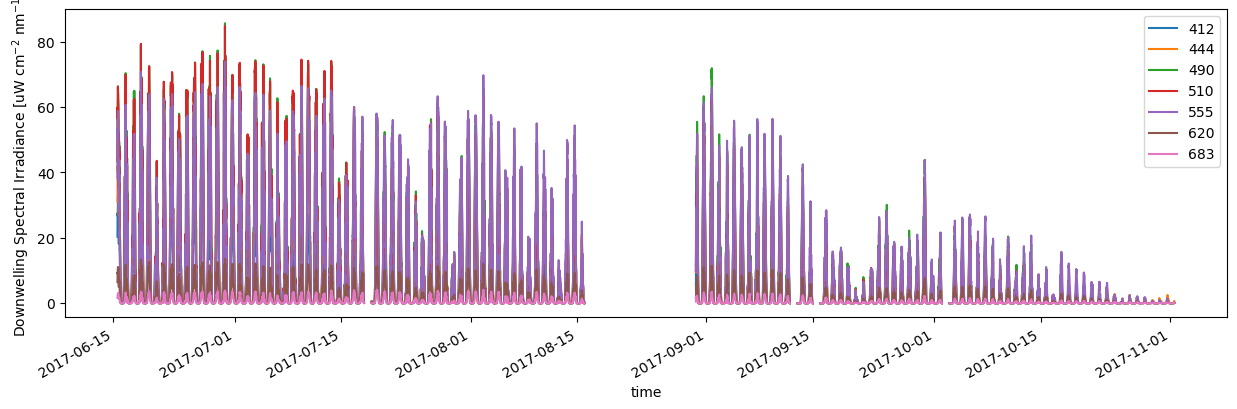

In [22]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

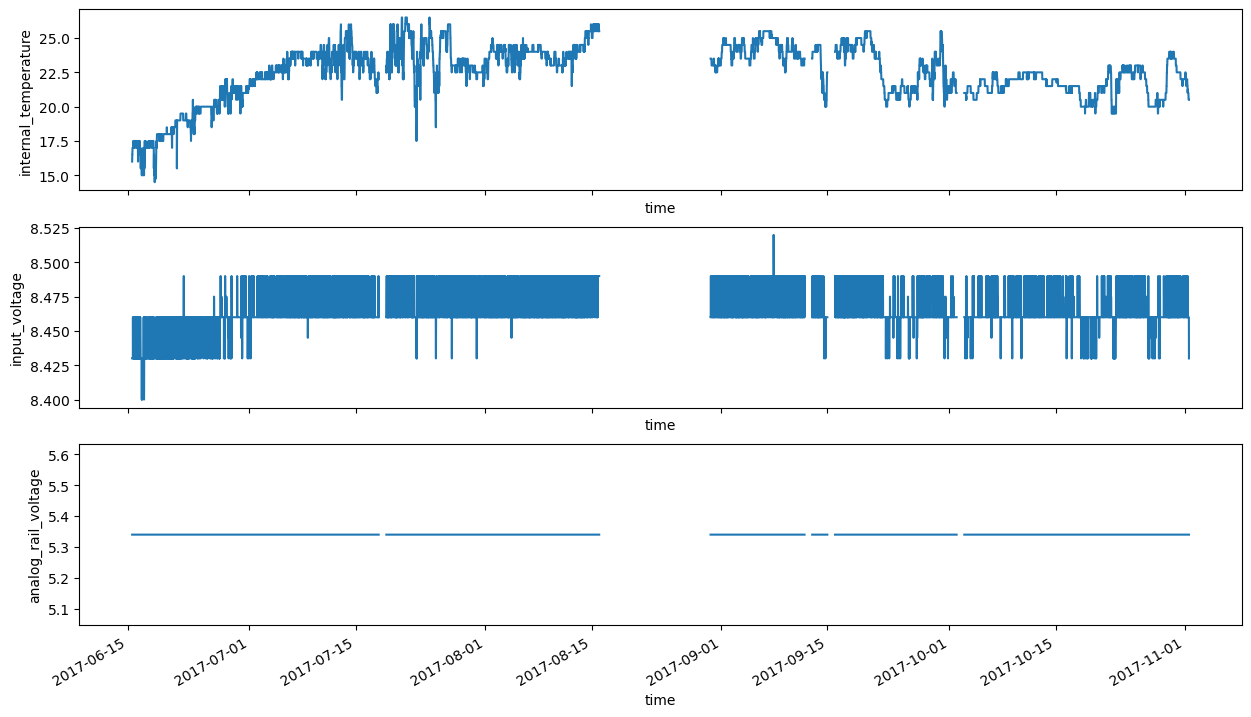

In [61]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

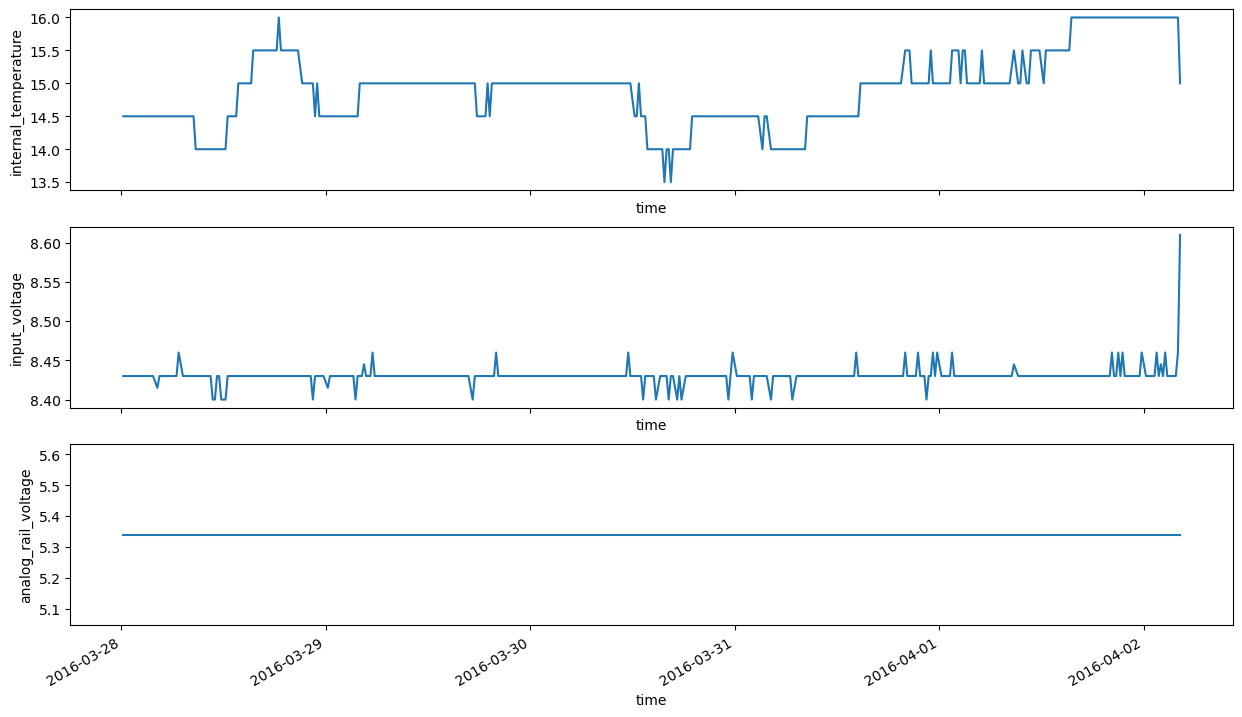

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

Loading and Processing Data Files: 100%|██████████| 1/1 [00:01<00:00,  1.78s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:03<00:00,  3.70s/it]


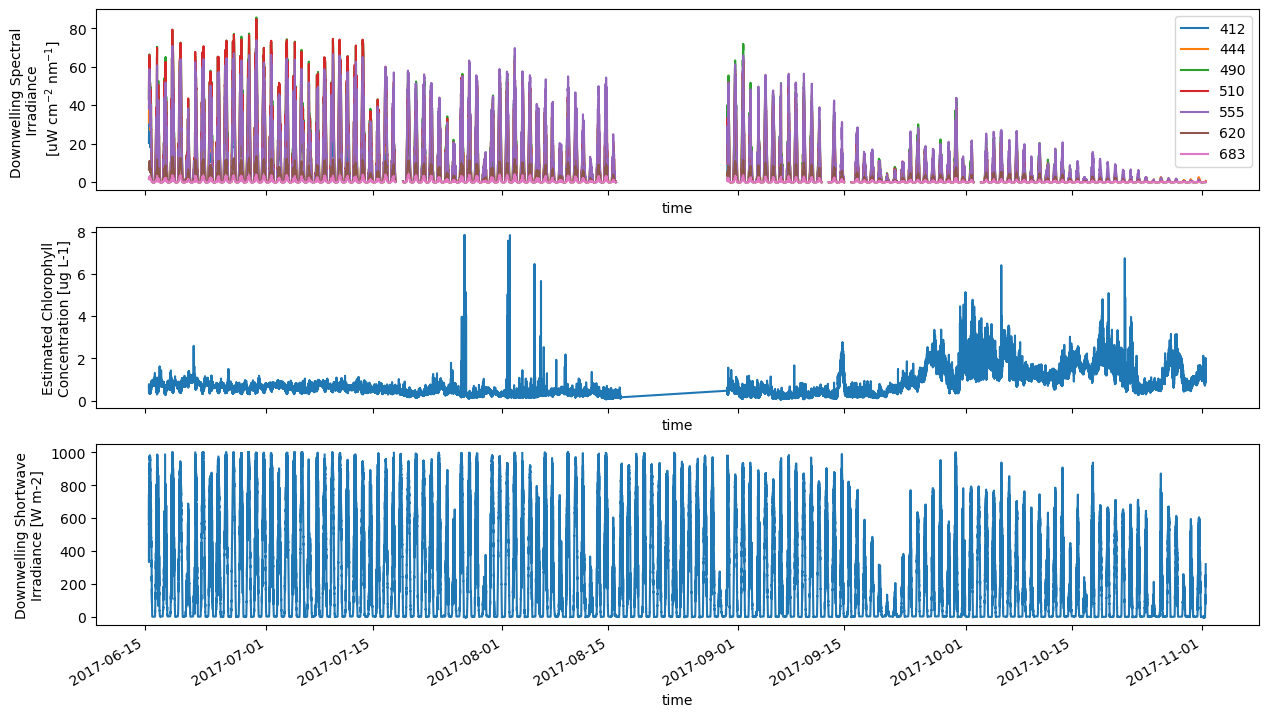

In [20]:
# Check behavior of shortwave irradiance and Chl-a during deployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, deploy, flort_node)

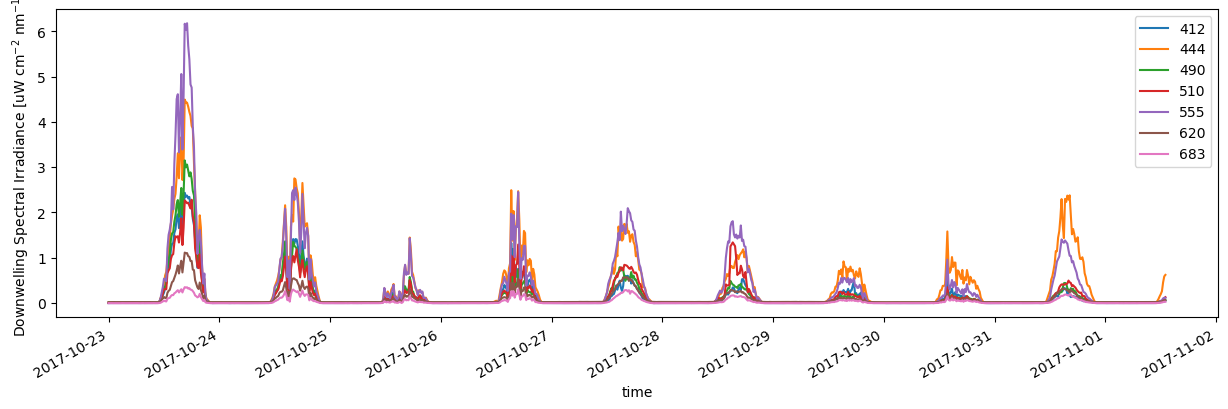

In [26]:
# Plot last week of data to look for best start date for annotation
spkir_end = spkir.sel(time=slice("10-23-2017","11-02-2017"))
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir_end.variables:
    if "downwelling_irradiance" in var:
        spkir_end[var].plot(ax=ax, label=spkir_end[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

I will get end date from last available data point (01-11-2017T13:00:00) and start date from the start of the prolonged spectral irradiance around 2 uW/cm2/nm or below (24-10-2017T00:00:00).

### Deployment 8

The downwelling irradiance signal drops off briefly in Oct 2018 but then recovers a little, so it was unclear whether biofouling was a strong possibility. 

Unfortunately the Chl-a record ends before Oct 2018, so we don't have any way to know whether a bloom could be affecting the penetrating light. However, the SWR from the METBK package shows that downwelling shortwave irradiance did not drop significantly from earlier in the deployment. It is unlikely that there was much cloudiness or a large decline of incident irradiance between summer and fall that would explain the decline in the SPKIR signal in October. In order for a plankton bloom to be responsible for the dip in downwelling irradiance intensity, it would have to be sustained for more than a month, which we don't normally see. I still suspect that something like biofouling has affected the data quality.

Our next task is checking spectral irradiance at the start of deployment 9 to make sure that the measured irradiance at the end of deployment 8 is uncharacteristic at this location and time.

Actually its looking kinda characteristic so not going to recommend an annotation

In [8]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 8

In [9]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.12s/it]


In [10]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [11]:
spkir = nanfill_time_gaps(spkir)

In [12]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 15197, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2018-03-25T15:30:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 8.5 8.5 ... 18.0 18.0
    input_voltage                  (station, time) float32 8.37 8.4 ... 8.46
    deployment                     (station, time) float32 8.0 8.0 ... 8.0 8.0
    analog_rail_voltage            (station, time) float32 5.34 5.34 ... 5.34
    raw_irradiance_412             (station, time) float32 2.231e+09 ... 2.15...
    raw_irradiance_444             (station, time) float32 2.291e+09 ... 2.15...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 2.093 ... 0.3542
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.37
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

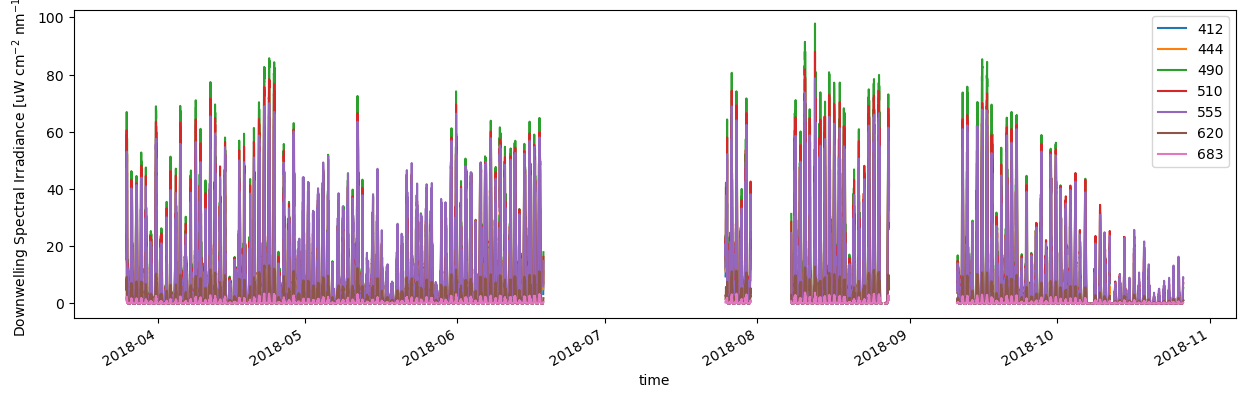

In [67]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

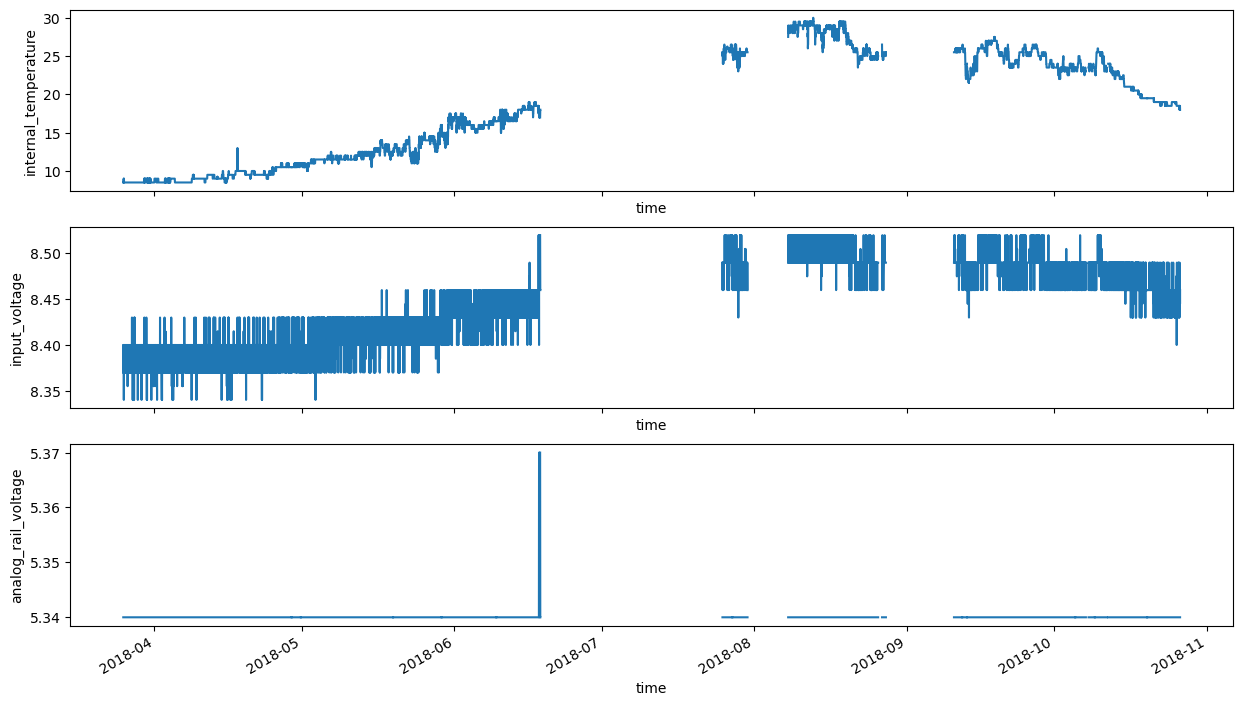

In [68]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

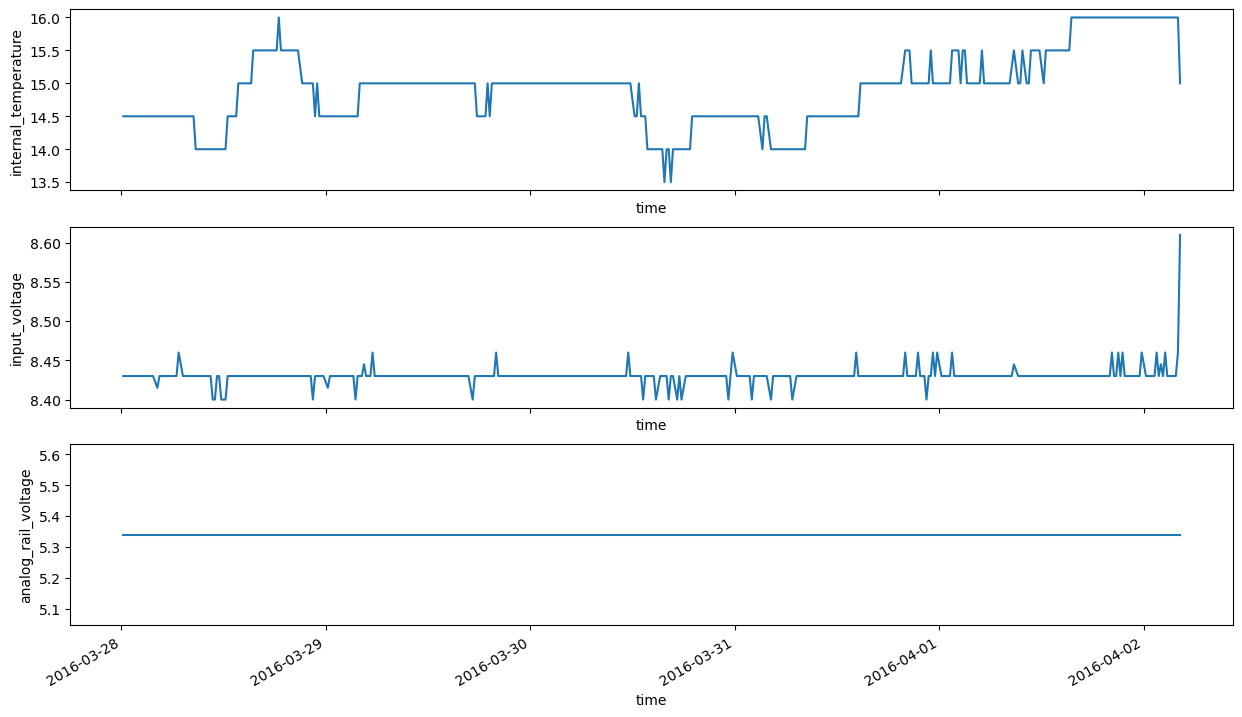

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

Loading and Processing Data Files: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:03<00:00,  3.19s/it]


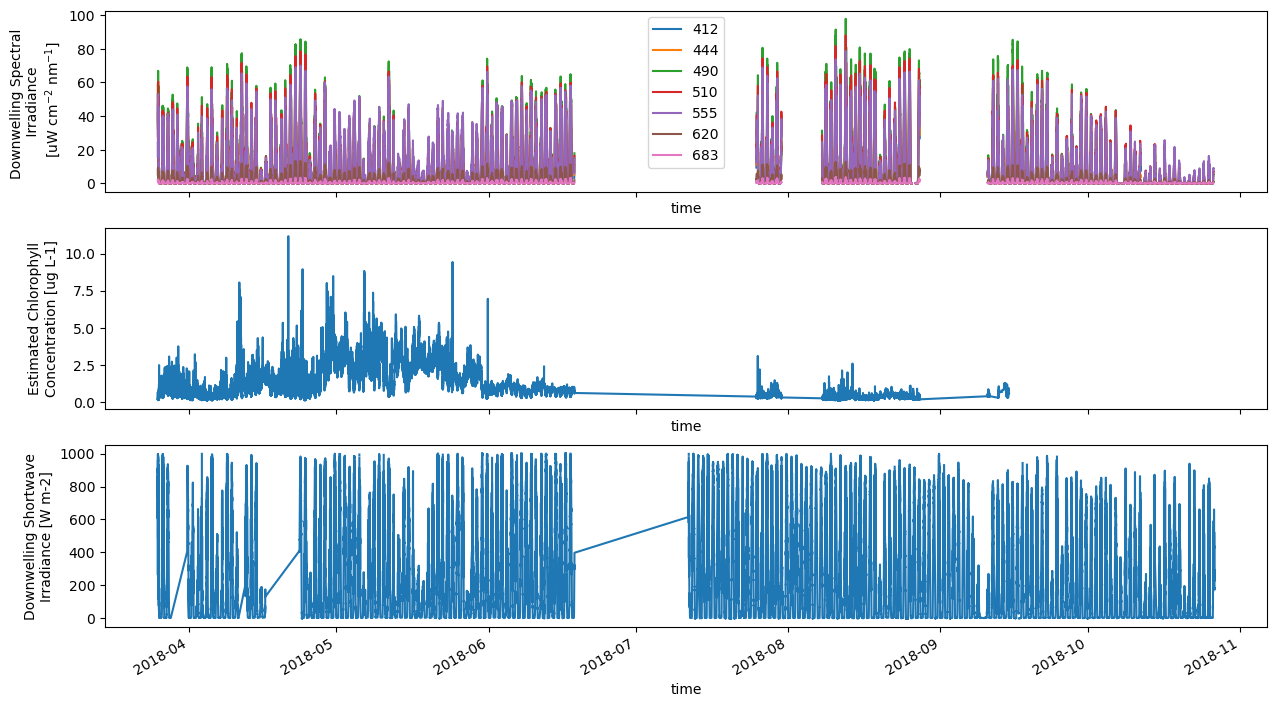

In [26]:
# Check behavior of shortwave irradiance and Chl-a during deployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, deploy, flort_node)

In [16]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, 'telemetered', 'spkir_abj_dcl_instrument', ('*deployment%04d*SPKIR*.nc' % 9))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.15s/it]


In [17]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations

In [18]:
spkir = nanfill_time_gaps(spkir)

In [19]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 14949, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2018-10-29T03:45:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 17.5 17.5 ... 9.0 9.0
    input_voltage                  (station, time) float32 8.49 8.46 ... 8.43
    deployment                     (station, time) float32 9.0 9.0 ... 9.0 9.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.31
    raw_irradiance_412             (station, time) float32 2.147e+09 ... 2.16...
    raw_irradiance_444             (station, time) float32 2.147e+09 ... 2.17...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 -0.0156 ... 0.7091
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.37
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  telemetered
    stream:                             spkir_abj_dcl_instrument
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

Loading and Processing Data Files: 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


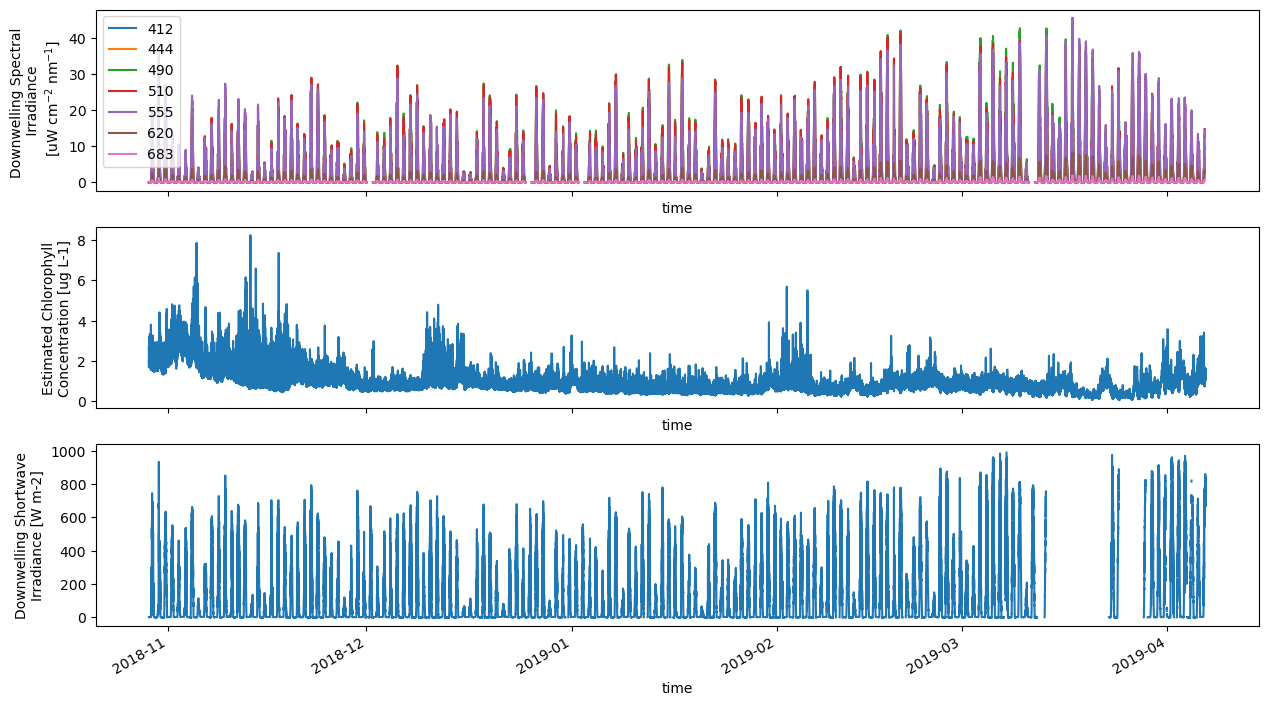

In [20]:
# Check behavior of shortwave irradiance and Chl-a during deployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, 9, flort_node)

### Deployment 11
 
 not_operational flag needs to be removed from current annotation or changed to only apply to telemetered data streams
 
 Still need to check whether adding a data delivery method filter to add_annotations_qc_flag fixes this issue, rather than editing an accurrate annotation.

In [69]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 11

In [70]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 2/2 [00:10<00:00,  5.48s/it]


In [71]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [72]:
spkir = nanfill_time_gaps(spkir)

In [73]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 38410, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2019-09-26T14:00:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 24.0 24.0 ... nan nan
    input_voltage                  (station, time) float32 8.49 8.49 ... nan nan
    deployment                     (station, time) float32 11.0 11.0 ... nan nan
    analog_rail_voltage            (station, time) float32 5.34 5.34 ... nan nan
    raw_irradiance_412             (station, time) float32 2.246e+09 ... nan
    raw_irradiance_444             (station, time) float32 2.292e+09 ... nan
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 1.381 1.575 ... nan
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... nan nan
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.36
    lon                            (station) float32 -70.89
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

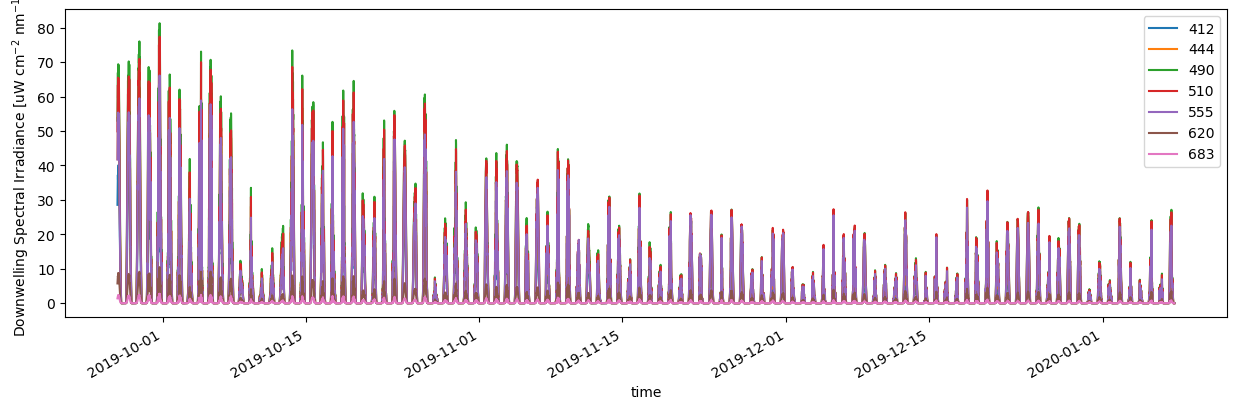

In [74]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

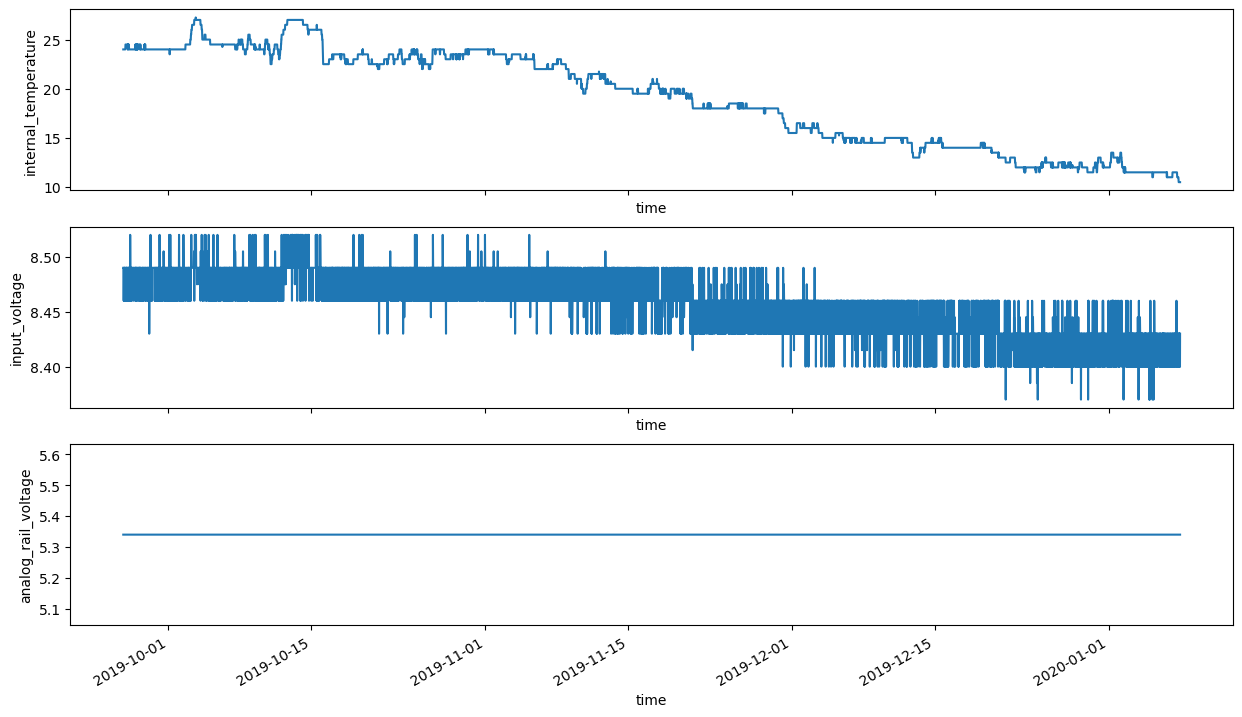

In [75]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

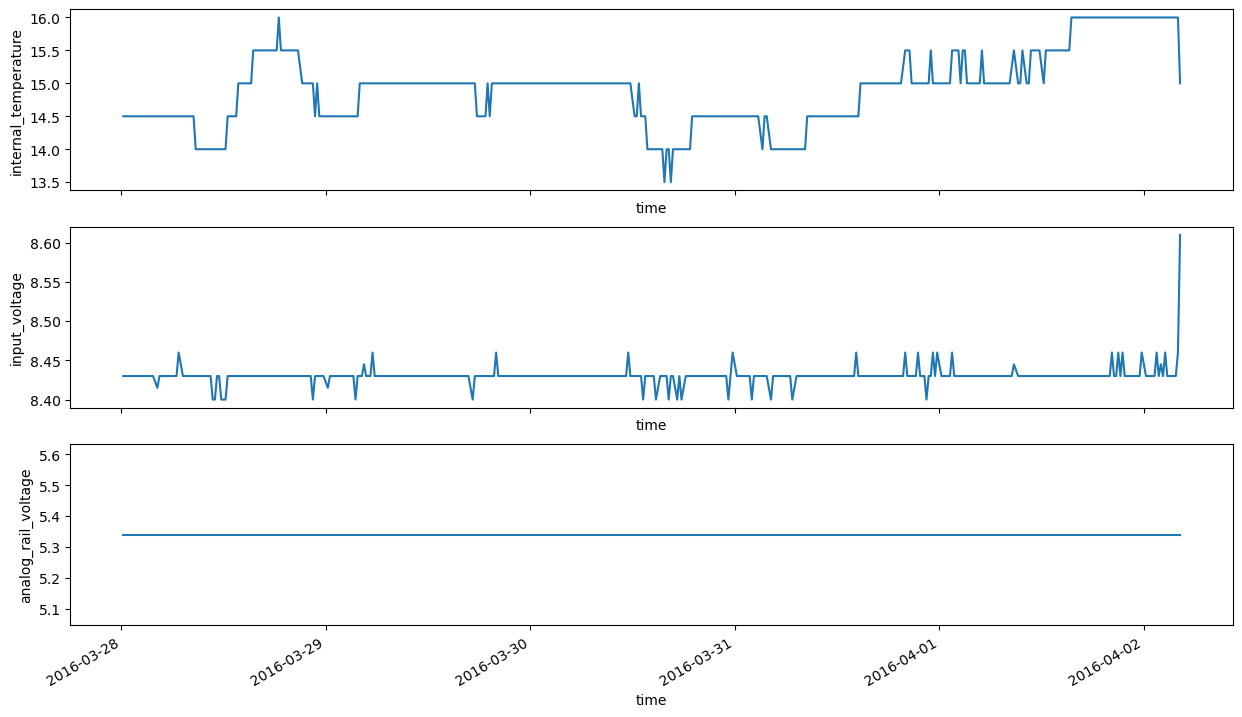

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

### Deployment 12

Unfortunately, the available Chl-a estimate from the FLORT ends around the same time that the spectral downwelling irradiance signal drops in all bands except for 490 nm. I still suspect biofouling because the behavior of the SPKIR signal agrees well with the SWR until the last month, around the start of March 2021.

Actually Deployment 13 shows similarly low values at the start and the tail end of an increase in chlorophyll in the water. There could have been a bloom around this time.

In [6]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 12

In [7]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:05<00:00,  5.28s/it]


In [8]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [9]:
spkir = nanfill_time_gaps(spkir)

In [10]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 14242, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2020-10-31T19:30:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 nan nan ... 8.5 8.5
    input_voltage                  (station, time) float32 nan nan ... 8.34 8.34
    deployment                     (station, time) float32 nan nan ... 12.0 12.0
    analog_rail_voltage            (station, time) float32 nan nan ... 5.31 5.31
    raw_irradiance_412             (station, time) float32 nan nan ... 2.147e+09
    raw_irradiance_444             (station, time) float32 nan nan ... 2.147e+09
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 nan nan ... -0.01381
    rollup_annotations_qc_results  (station, time) float32 nan nan ... 3.0 3.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.37
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

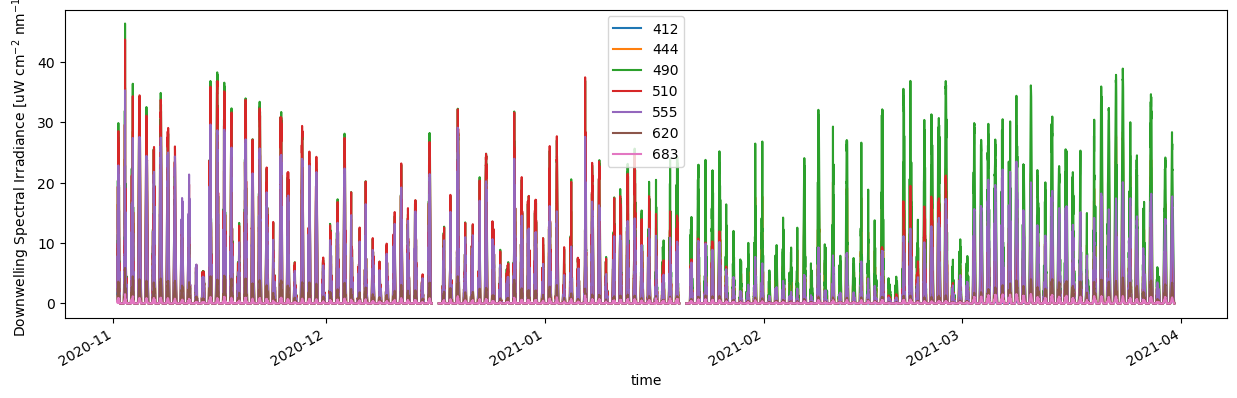

In [81]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

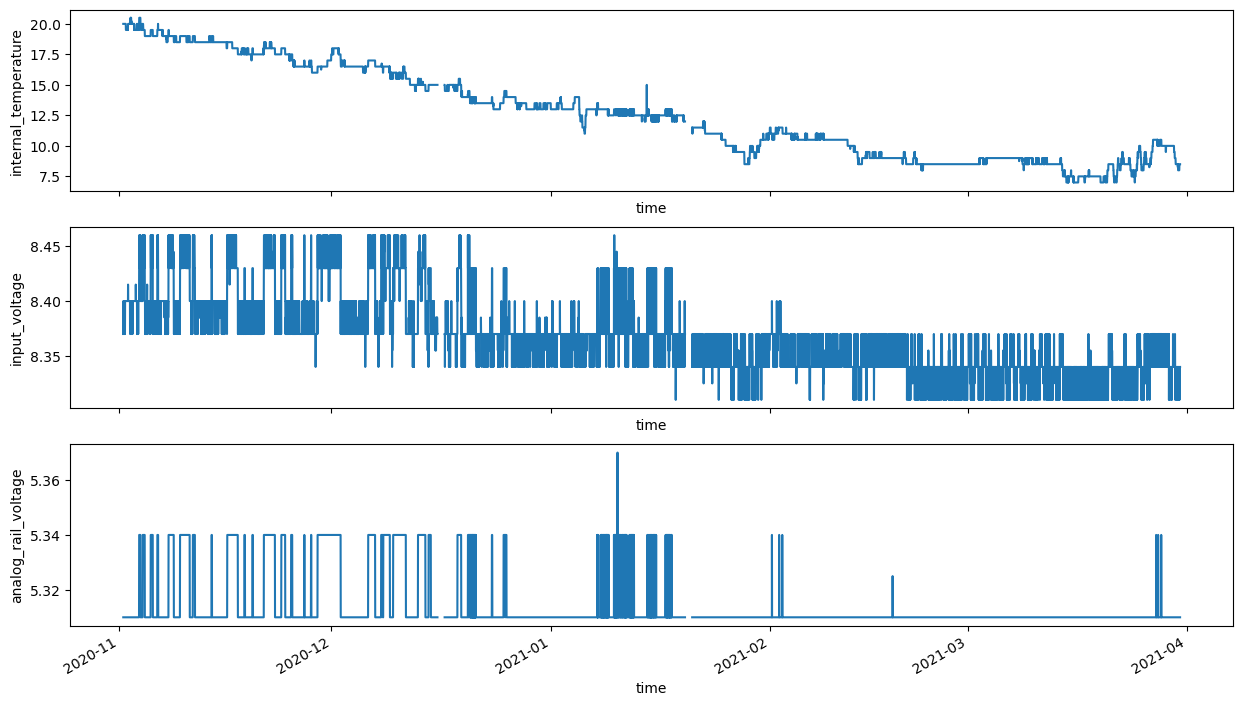

In [82]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

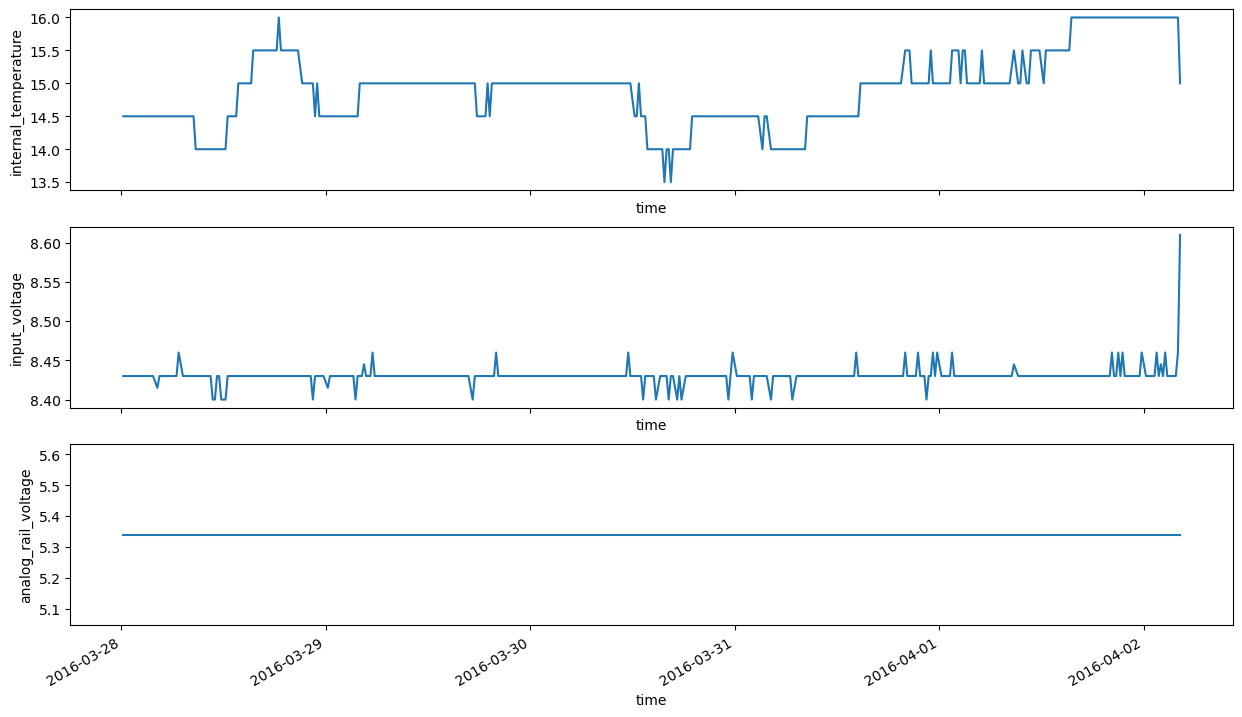

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

Loading and Processing Data Files: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:03<00:00,  3.42s/it]


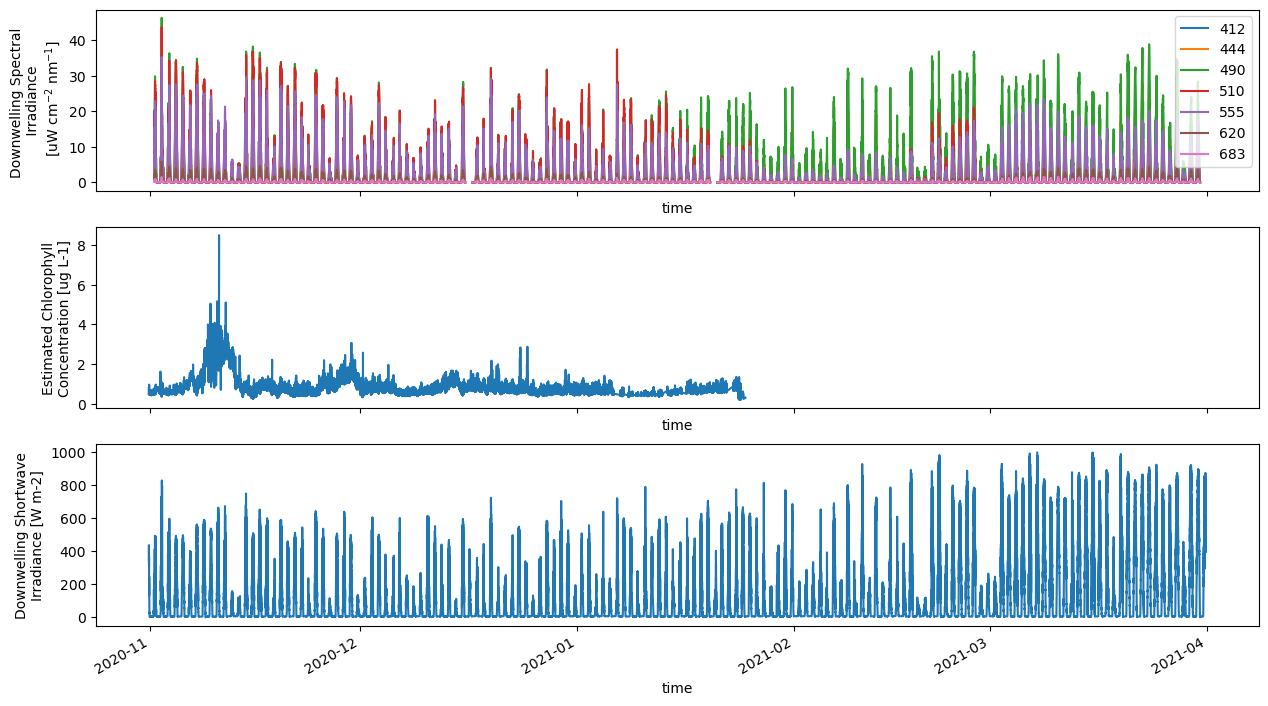

In [11]:
# Check behavior of shortwave irradiance and Chl-a during deployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, deploy, flort_node)

### Deployment 13

Depending on the final decision, we could update existing annotation to add a suspect flag, or add a new annotation with a suspect qc flag for reduced irradiance magnitude once NSIF powered back on.

The SWR from the METBK shows a gradual falling trend compared to the SPKIR and that observations remained fairly steady during the time that the NSIF was shut off. Since the SPKIR observations start at a lower intensity of light and don't show a clearly falling trend, I would expect that biofouling was present from the time the NSIF was turned back on. There were a few spikes in the Chl-a estimate during this part of the deployment, and I think these contributed to additional reduced signal from the SPKIR for brief periods.

In [28]:
# Current annotation messages for deployment 13
print(annotations['annotation'][3])
print(annotations['annotation'][4])
print(annotations['annotation'][5])

Deployment 13: * UPDATED 2021-09-11: NSIF power was restored 8/13/21 but disabled again 8/22/21 through 8/31/21. * NSIF power was disabled on 8/4/21 due to the buoy's low power state and it will be powered back on when voltage levels rebound. No telemetered data expected for this time period. Instruments that do not collect data on battery power will have a gap in their recovered data for this period.
Deployment 13: A gap exists in the telemetered data for all NSIF instruments between 10/2/21 and 10/11/21 due to a telemetry issue. These instruments were powered and sampling and data should be available upon recovery.
Deployment 13: On recovery biofouling was observed on the optical windows. The UV-light was powered off for approximately 1 month in August when the NSIF was shut down due to low power.


In [29]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]
deploy = 13

In [30]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*deployment%04d*SPKIR*.nc' % deploy))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.02s/it]


In [31]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations
    # spkir = spkir.where(spkir. # not sure which summary_qc variables are in here that I should use for this part -- there isn't such a variable in these datasets

In [32]:
spkir = nanfill_time_gaps(spkir)

In [33]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (time: 18934, station: 1)
Coordinates:
  * time                           (time) datetime64[ns] 2021-04-02T20:45:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 12.5 11.5 ... 19.5
    input_voltage                  (station, time) float32 8.31 8.31 ... 8.34
    deployment                     (station, time) float32 13.0 13.0 ... 13.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.31
    raw_irradiance_412             (station, time) float32 2.15e+09 ... 2.148...
    raw_irradiance_444             (station, time) float32 2.152e+09 ... 2.14...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 0.11 ... 0.01645
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.37
    lon                            (station) float32 -70.88
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

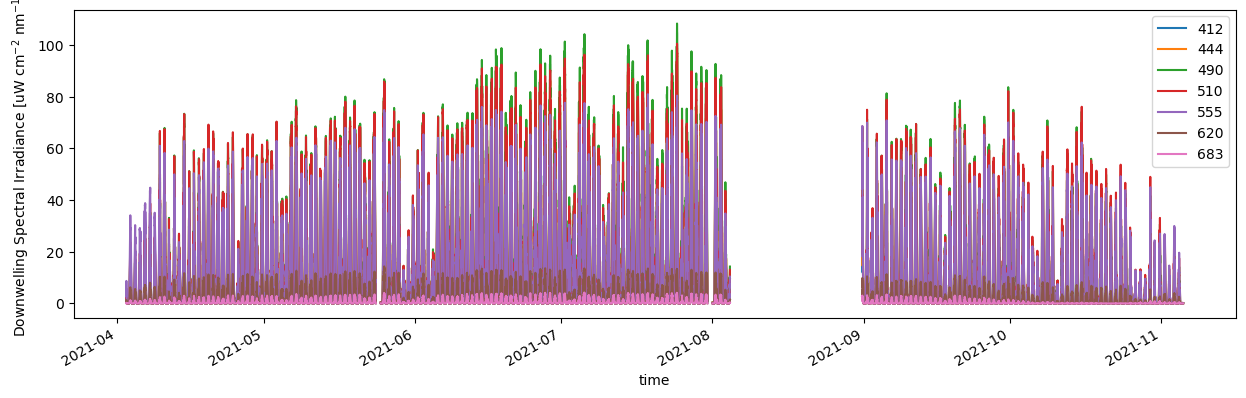

In [88]:
# First plot edited data to check whether inserting nans over gaps in time coverage is necessary
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

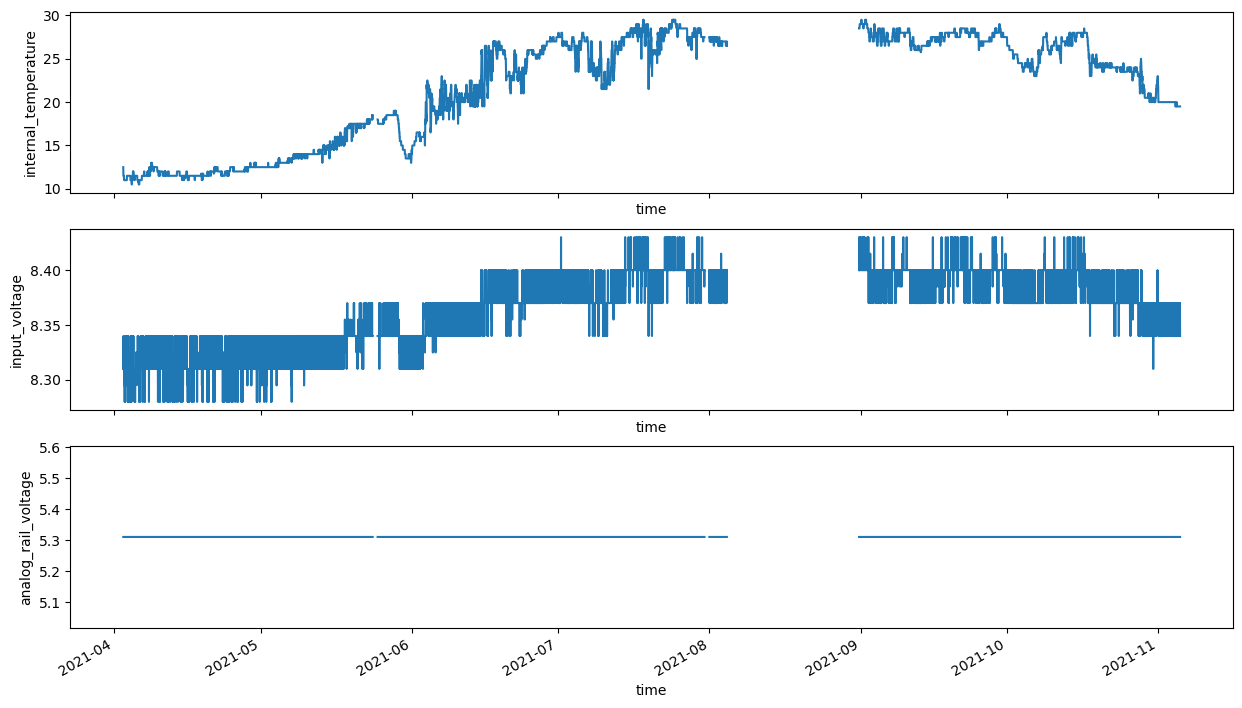

In [89]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].plot.line(ax=ax[0])
spkir.input_voltage[0].plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].plot.line(ax=ax[2])

In [ ]:
# plot a shorter time series 
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        spkir[var].sel(time=slice('2016-03-28','2016-04-04')).plot(ax=ax, label=spkir[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

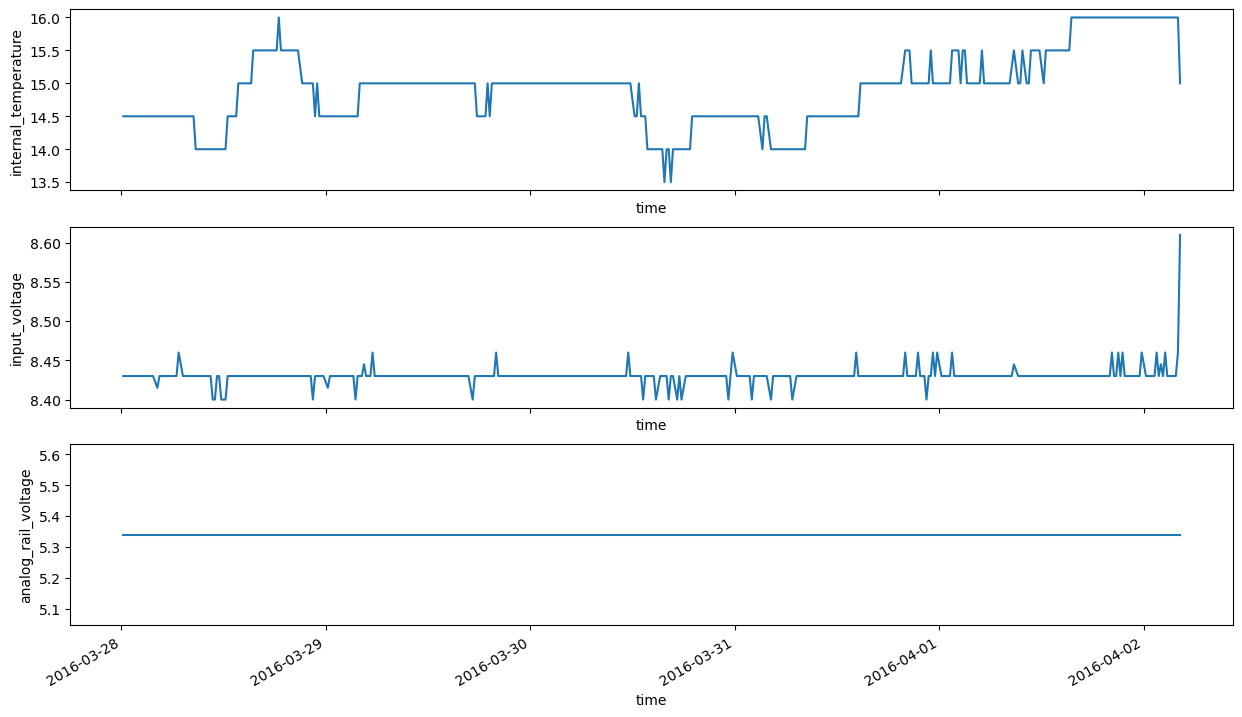

In [58]:
#  Checking internal temperature, supply voltage, and analog rail voltage during this time
fig, ax = plt.subplots(3,1, sharex=True, figsize=(15,8))
spkir.internal_temperature[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[0])
spkir.input_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[1])
spkir.analog_rail_voltage[0].sel(time=slice('2016-03-28','2016-04-04')).plot.line(ax=ax[2])

Loading and Processing Data Files: 100%|██████████| 1/1 [00:02<00:00,  2.51s/it]


Loading and Processing Data Files: 100%|██████████| 1/1 [00:04<00:00,  4.77s/it]


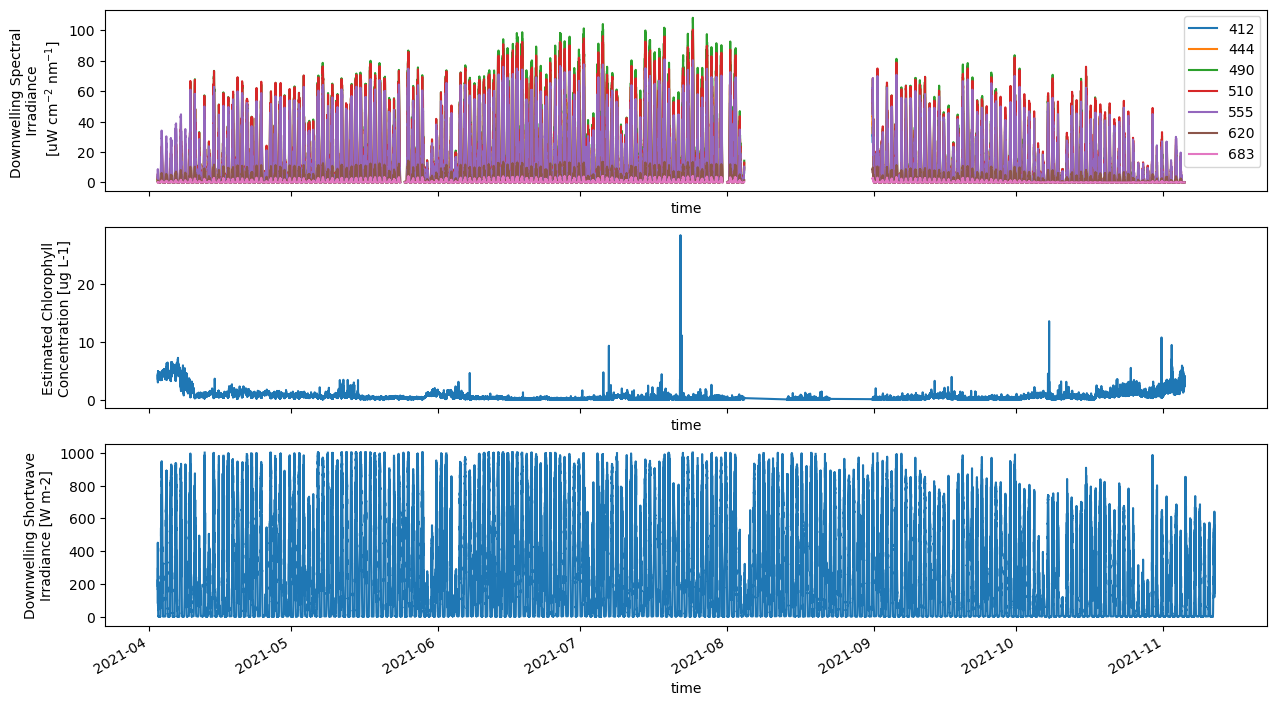

In [20]:
# Check behavior of shortwave irradiance and Chl-a during d eployment
metbk, flort, fig, ax = check_chla_swr(spkir, site, deploy)

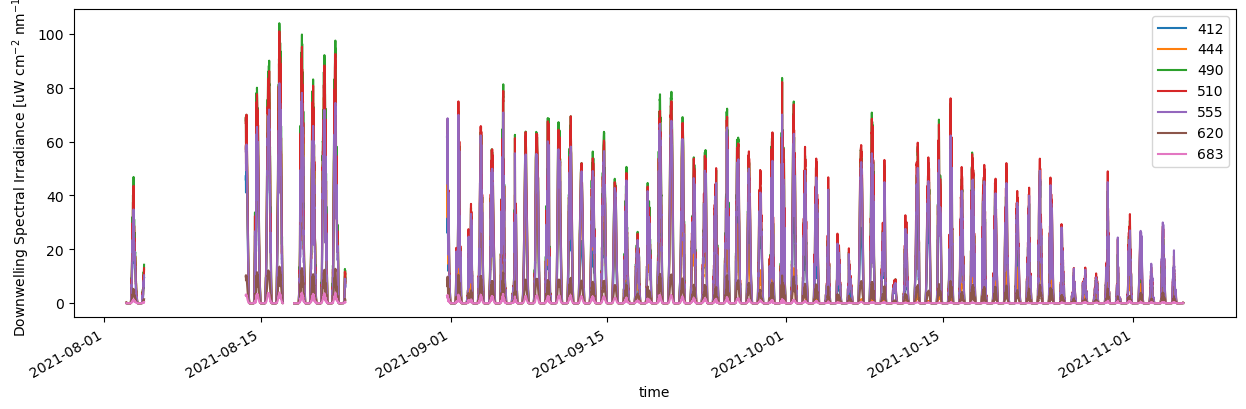

In [34]:
# Check that existing annotation dates will continue to work for updated annotation
spkir_end = spkir.sel(time=slice("08-03-2021","11-11-2021"))
fig, ax = plt.subplots(1,1,figsize=(15,4))
for var in spkir_end.variables:
    if "downwelling_irradiance" in var:
        spkir_end[var].plot(ax=ax, label=spkir_end[var].radiation_wavelength)
ax.set_ylabel('Downwelling Spectral Irradiance [uW cm$^{-2}$ nm$^{-1}$]')
plt.legend()

### Histograms of downwelling irradiance measurements

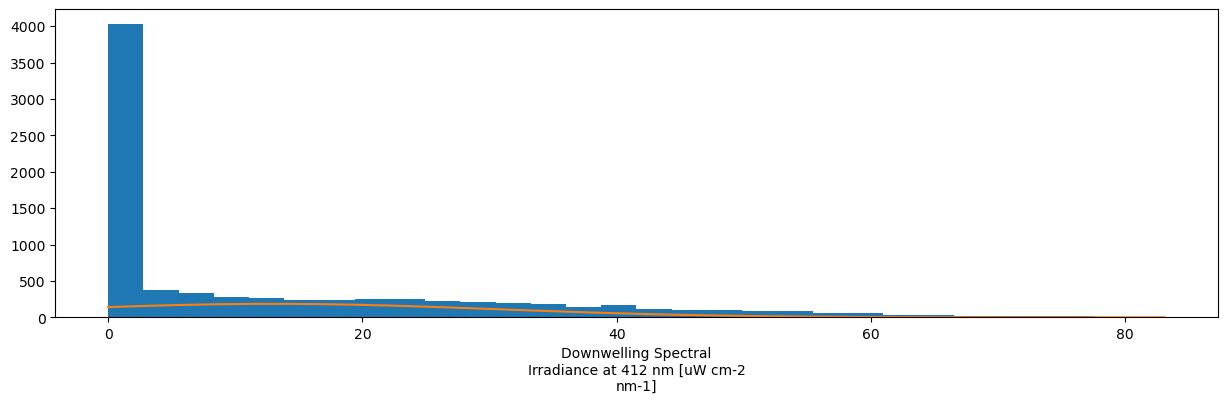

In [30]:
# histogram of downwelling irradiance @ 412 nm variable
irrad412 = spkir['downwelling_irradiance_412'][0]
# irrad412 = spkir['downwelling_irradiance_412'][0].sel(time=slice('2017-07-01'))
mu412 = irrad412.mean()
sig412 = irrad412.std()

plt.figure(figsize=(15,4))
c, x, h = irrad412.plot.hist(bins=30)
norm412 = sum(c)*norm.pdf(x, mu412, sig412)
plt.plot(x, norm412)

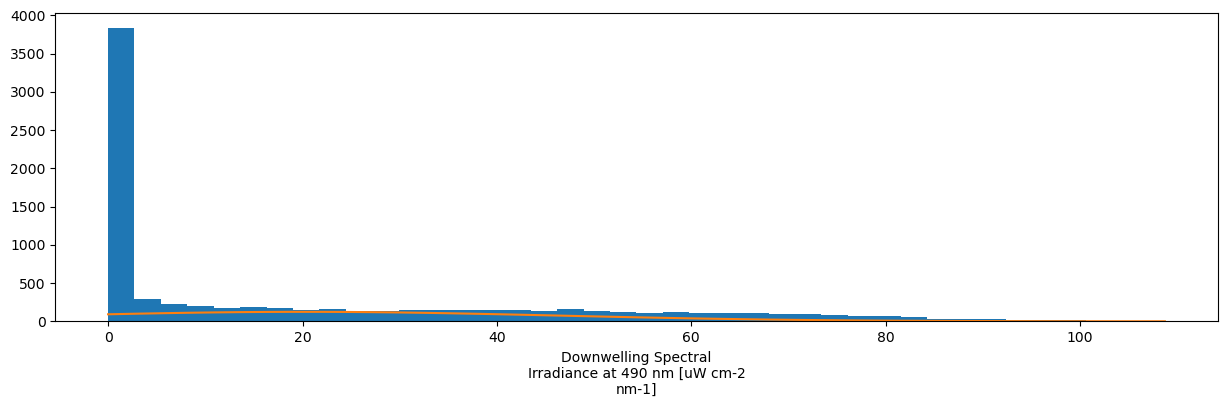

In [31]:
# histogram of downwelling irradiance @ 490 nm variable
irrad490 = spkir['downwelling_irradiance_490'][0]
# irrad490 = spkir['downwelling_irradiance_490'][0].sel(time=slice('2017-07-01'))
mu490 = irrad490.mean()
sig490 = irrad490.std()

plt.figure(figsize=(15,4))
c, x, h = irrad490.plot.hist(bins=40)
norm490 = sum(c)*norm.pdf(x, mu490, sig490)
plt.plot(x, norm490)

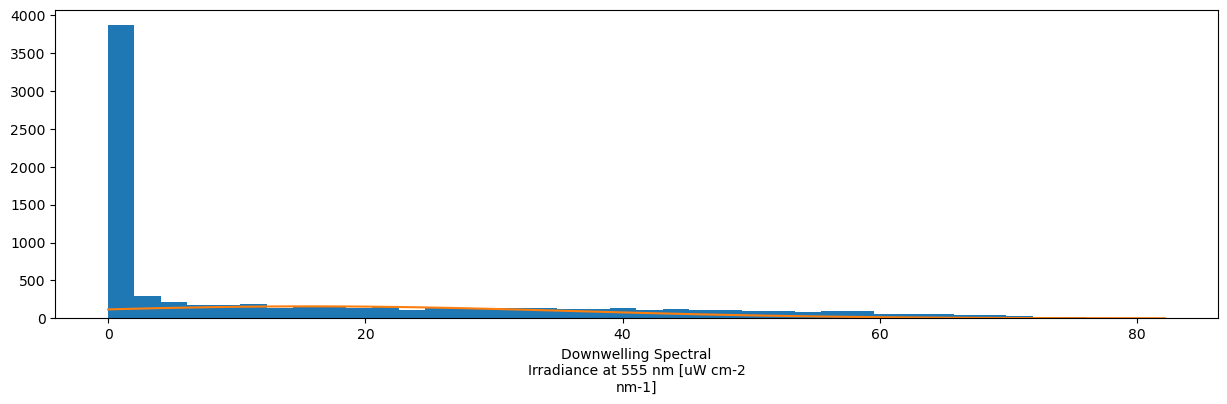

In [32]:
# histogram of downwelling irradiance @ 555 nm variable
irrad555 = spkir['downwelling_irradiance_555'][0]
# irrad555 = spkir['downwelling_irradiance_555'][0].sel(time=slice('2015-06-01'))
mu555 = irrad555.mean()
sig555 = irrad555.std()

plt.figure(figsize=(15,4))
c, x, h = irrad555.plot.hist(bins=40)
norm555 = sum(c)*norm.pdf(x, mu555, sig555)
plt.plot(x, norm555)

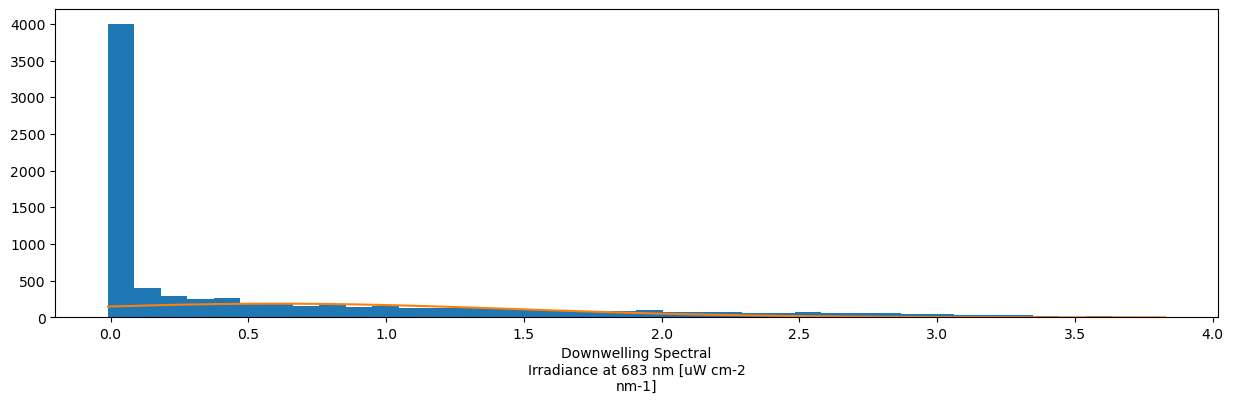

In [33]:
# histogram of downwelling irradiance @ 683 nm variable
irrad683 = spkir['downwelling_irradiance_683'][0]
# irrad683 = spkir['downwelling_irradiance_683'][0].sel(time=slice('2017-07-01'))
mu683 = irrad683.mean()
sig683 = irrad683.std()

plt.figure(figsize=(15,4))
c, x, h = irrad683.plot.hist(bins=40)
norm683 = 0.05*sum(c)*norm.pdf(x, mu683, sig683)
plt.plot(x, norm683)

In [34]:
# concat the different irradiance variables for histogram of all irradiance values
irradAll = xr.DataArray()
for var in spkir.variables:
    if "downwelling_irradiance" in var:
        irradAll = xr.concat([irradAll, spkir[var][0]], dim='channel')
irradAll

<xarray.DataArray (channel: 8, time: 8581)>
array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [-1.24489265e-02, -1.22679379e-02, -1.27385072e-02, ...,
         3.33838081e+01,  2.91790657e+01,  2.71376114e+01],
       [-2.28602290e-02, -2.30053701e-02, -2.28148736e-02, ...,
         4.15520287e+01,  3.64205742e+01,  3.37744560e+01],
       ...,
       [-8.62311665e-03, -7.81955104e-03, -8.97590257e-03, ...,
         3.88252945e+01,  3.34404564e+01,  3.07892475e+01],
       [ 1.19705470e-02,  1.19244633e-02,  1.15373600e-02, ...,
         4.89614058e+00,  4.12962008e+00,  3.72692156e+00],
       [-4.96644620e-03, -5.32475766e-03, -4.51855734e-03, ...,
         1.25258076e+00,  1.05488253e+00,  9.43447709e-01]])
Coordinates:
  * time     (time) datetime64[ns] 2015-05-09T01:00:00 ... 2015-09-28T19:45:00
Dimensions without coordinates: channel

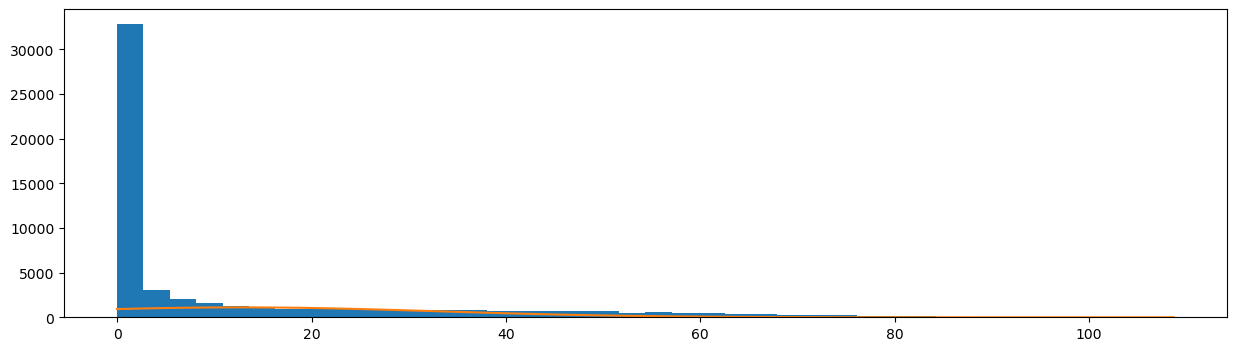

In [35]:
# histogram using all irradiance values
radAll= irradAll
muAll = radAll.mean()
sigAll = radAll.std()

plt.figure(figsize=(15,4))
c, x, h = radAll.plot.hist(bins=40)
normAll = sum(c)*norm.pdf(x, muAll, sigAll)
plt.plot(x, normAll)

### Histograms after monthly mean filter

### Spectrograms of downwelling irradiance (not burst averaged)

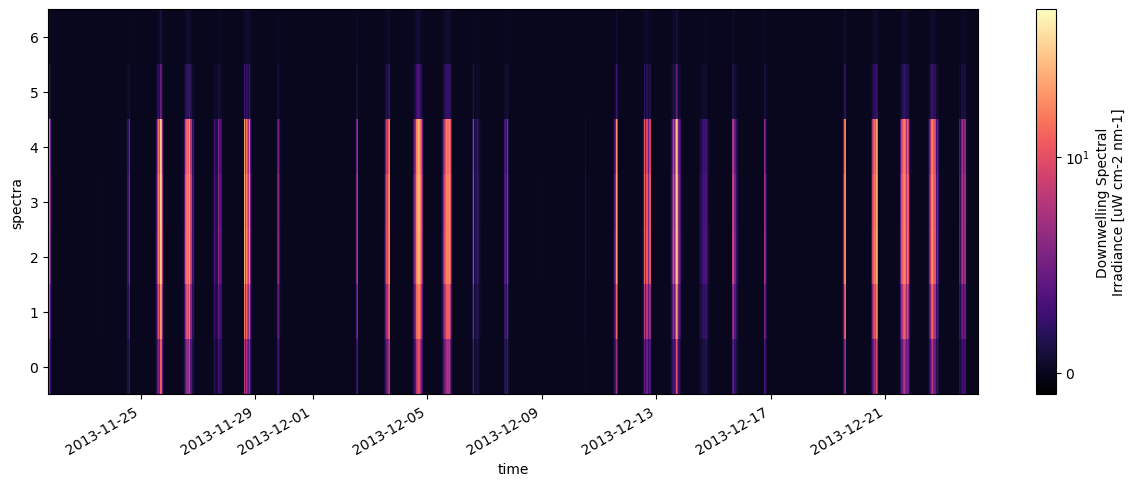

In [20]:
# Trying same plot with full resolution data with log-scale colormap (linear between -1,10)
xr.plot.pcolormesh(spkir_full_time.spkir_abj_cspp_downwelling_vector, x="time", y="spectra", cmap='magma', figsize=(15,5), norm=colors.SymLogNorm(linthresh=10, vmin=-1))

In [28]:
# That was a bad idea so let's resample to daily
downwelling_irradiance = spkir_full_time.spkir_abj_cspp_downwelling_vector
downwelling_irradiance = downwelling_irradiance.resample(time="1D").median("time")
downwelling_irradiance

<xarray.DataArray 'spkir_abj_cspp_downwelling_vector' (time: 174, spectra: 7)>
array([[ 9.71255556e+00,  1.33028855e+01,  1.93817753e+01, ...,
         2.23164523e+01,  3.62021577e+00,  7.82912088e-01],
       [ 6.20054185e-01,  9.06080839e-01,  1.34600973e+00, ...,
         1.25914219e+00,  1.82409459e-01,  5.95385999e-02],
       [ 1.73746901e-01,  2.63608506e-01,  3.78101900e-01, ...,
         4.27118953e-01,  6.74665225e-02,  3.25888514e-02],
       ...,
       [ 7.39844170e-02,  7.86333704e-02,  8.35438973e-02, ...,
         5.61443408e-02,  8.31668786e-03,  4.77597635e-03],
       [ 2.28589437e-01,  2.76852485e-01,  3.28657073e-01, ...,
         2.09412793e-01,  2.62619446e-02,  1.17360818e-02],
       [ 2.29803754e-03,  3.92295552e-04, -2.80754229e-04, ...,
        -6.79578805e-04,  1.25565920e-03,  3.28846042e-03]])
Coordinates:
  * spectra  (spectra) int32 0 1 2 3 4 5 6
  * time     (time) datetime64[ns] 2019-04-06 2019-04-07 ... 2019-09-26
Attributes:
    _FillValue:               -9999999.0
    comment:                  Downwelling Spectral Irradiance is the measure ...
    long_name:                Downwelling Spectral Irradiance
    precision:                4
    coordinates:              time lat lon
    data_product_identifier:  SPECTIR_L1
    units:                    uW cm-2 nm-1
    ancillary_variables:      channel_array

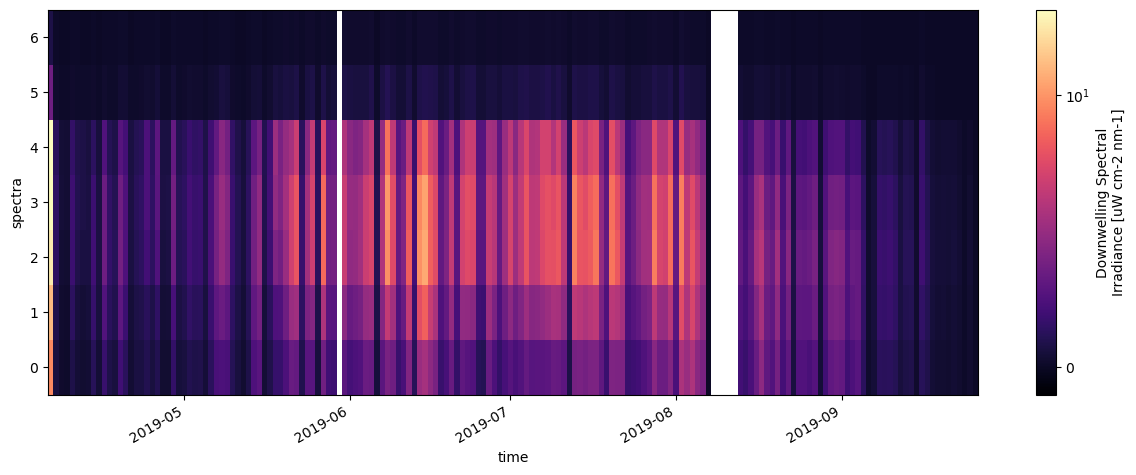

In [30]:
# pcolormesh plot with log-scale cmap except for [-1, 10] which is linear
xr.plot.pcolormesh(downwelling_irradiance, x="time", y="spectra", cmap='magma', figsize=(15,5), norm=colors.SymLogNorm(linthresh=10, vmin=-1))

In [31]:
# Now lets try this with a 5-day median resample
downwelling_irradiance = spkir_full_time.spkir_abj_cspp_downwelling_vector
downwelling_irradiance = downwelling_irradiance.resample(time="5D").median("time")
downwelling_irradiance

<xarray.DataArray 'spkir_abj_cspp_downwelling_vector' (time: 35, spectra: 7)>
array([[6.82127204e-01, 9.39339140e-01, 1.49556243e+00, 1.66573864e+00,
        1.50775647e+00, 2.17019475e-01, 6.62599682e-02],
       [4.09351526e-01, 5.97971766e-01, 8.23282033e-01, 8.41685295e-01,
        7.24953008e-01, 1.07756459e-01, 4.46083474e-02],
       [1.11149060e+00, 1.63481436e+00, 2.06272259e+00, 1.99825457e+00,
        1.42778278e+00, 2.07900504e-01, 6.89136231e-02],
       [6.33905790e-01, 8.30168475e-01, 1.26737414e+00, 1.37036116e+00,
        1.22211412e+00, 1.81988724e-01, 5.88591173e-02],
       [4.88950510e-01, 7.05335209e-01, 1.08804481e+00, 1.18094031e+00,
        1.09429885e+00, 1.71634988e-01, 5.71144999e-02],
       [6.95715056e-01, 9.77443677e-01, 1.34453113e+00, 1.40168619e+00,
        1.25158622e+00, 1.94583331e-01, 6.10077514e-02],
       [1.77887788e+00, 2.40299210e+00, 3.25211386e+00, 3.32345650e+00,
        2.82799702e+00, 3.63398624e-01, 9.33474496e-02],
       [8.35149703e-01, 1.11870379e+00, 1.48298037e+00, 1.51192503e+00,
        1.28393037e+00, 1.92699171e-01, 5.95294177e-02],
       [1.19328147e+00, 1.70288643e+00, 2.52271664e+00, 2.78847411e+00,
        2.70395010e+00, 3.80136554e-01, 1.00454470e-01],
       [2.62830054e+00, 3.91435216e+00, 5.20132994e+00, 5.24724249e+00,
        4.42306642e+00, 5.73875815e-01, 1.45943075e-01],
...
       [2.06008457e+00, 2.58632186e+00, 3.16383481e+00, 2.98038643e+00,
        2.42941038e+00, 3.60160794e-01, 9.68550489e-02],
       [2.74753531e+00, 3.09858421e+00, 3.49182410e+00, 3.13586101e+00,
        2.39268108e+00, 3.07221372e-01, 8.25675502e-02],
       [2.20276612e+00, 2.58443371e+00, 2.88604360e+00, 2.58521177e+00,
        1.98243281e+00, 2.43159916e-01, 6.05670060e-02],
       [1.66826512e+00, 2.02154214e+00, 2.23259445e+00, 1.97611683e+00,
        1.40635816e+00, 1.69531314e-01, 4.33503864e-02],
       [2.70608963e+00, 3.34031155e+00, 3.58219552e+00, 3.11022829e+00,
        2.22732694e+00, 2.56595992e-01, 6.27982799e-02],
       [7.45937359e-01, 8.52196817e-01, 9.00792402e-01, 7.83724039e-01,
        6.10910023e-01, 8.67380087e-02, 2.31770994e-02],
       [1.05503826e+00, 1.35776975e+00, 1.46589740e+00, 1.28284831e+00,
        9.28877248e-01, 1.16683356e-01, 3.63260056e-02],
       [7.11412936e-01, 9.11214792e-01, 1.05646410e+00, 9.39103459e-01,
        7.16780233e-01, 8.74880143e-02, 2.91914385e-02],
       [3.15291575e-01, 3.98664721e-01, 4.91061523e-01, 4.47583359e-01,
        3.45641780e-01, 4.67864891e-02, 1.80901622e-02],
       [6.95465087e-03, 5.62515071e-03, 3.77377740e-03, 2.68314116e-03,
        3.17550394e-03, 3.19469816e-03, 4.37195968e-03]])
Coordinates:
  * spectra  (spectra) int32 0 1 2 3 4 5 6
  * time     (time) datetime64[ns] 2019-04-06 2019-04-11 ... 2019-09-23
Attributes:
    _FillValue:               -9999999.0
    comment:                  Downwelling Spectral Irradiance is the measure ...
    long_name:                Downwelling Spectral Irradiance
    precision:                4
    coordinates:              time lat lon
    data_product_identifier:  SPECTIR_L1
    units:                    uW cm-2 nm-1
    ancillary_variables:      channel_array

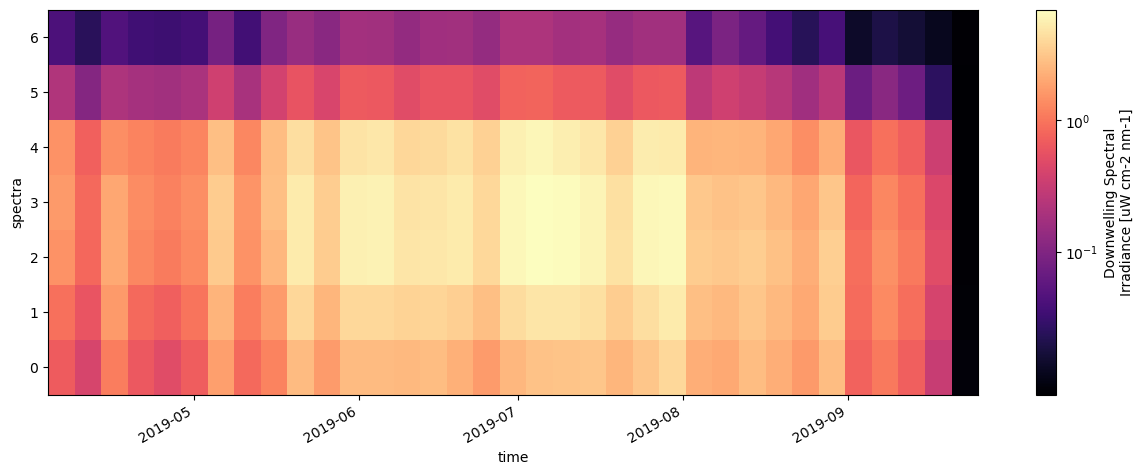

In [37]:
# 5-day median of downwelling spectral irradiance pcolormesh plot with log-scale cmap except for [0, 0.01] which is linear
xr.plot.pcolormesh(downwelling_irradiance, x="time", y="spectra", cmap='magma', figsize=(15,5), norm=colors.SymLogNorm(linthresh=0.1))

### Check annotations to be added with time series

In [7]:
# Set method and stream strings
method = methods[0]
stream = streams[method][0]

In [8]:
# Request annotations and load data from the local kdata directory
annotations = get_annotations(site, node, sensor)
annotations = pd.DataFrame(annotations)
spkir = load_kdata(site, node, sensor, method, stream, ('*SPKIR*.nc'))
spkir = spkir_datalogger(spkir, burst=True)

Loading and Processing Data Files: 100%|██████████| 17/17 [00:54<00:00,  3.18s/it]


In [9]:
# Add qc flags for annotations retrieved above
if not annotations.empty:
    # create an annotation-based quality flag
    spkir = add_annotation_qc_flags(spkir, annotations)

    # clean-up the data, removing values that were marked as fail either from the quality checks or in the
    # annotations
    spkir = spkir.where(spkir.rollup_annotations_qc_results < 4) # flags from annotations

In [10]:
# Check structure of edited data and contents
vocab = get_vocabulary(site, node, sensor)[0]
spkir = update_dataset(spkir, vocab['maxdepth'])
spkir['time'] = pd.to_datetime(spkir.time, unit='s')
spkir

<xarray.Dataset>
Dimensions:                        (station: 1, time: 222479)
Coordinates:
  * time                           (time) datetime64[ns] 2015-05-09T01:00:00 ...
Dimensions without coordinates: station
Data variables: (12/23)
    internal_temperature           (station, time) float32 11.5 11.0 ... 21.0
    input_voltage                  (station, time) float32 8.37 8.37 ... 8.4 8.4
    deployment                     (station, time) float32 2.0 2.0 ... 15.0 15.0
    analog_rail_voltage            (station, time) float32 5.31 5.31 ... 5.34
    raw_irradiance_412             (station, time) float32 2.147e+09 ... 2.14...
    raw_irradiance_444             (station, time) float32 2.147e+09 ... 2.15...
    ...                             ...
    downwelling_irradiance_683     (station, time) float32 -0.004966 ... 0.03828
    rollup_annotations_qc_results  (station, time) float32 0.0 0.0 ... 0.0 0.0
    station_name                   (station) <U8 'CP03ISSM'
    lat                            (station) float32 40.36
    lon                            (station) float32 -70.89
    z                              (station) float32 7.0
Attributes: (12/69)
    node:                               RID26
    comment:                            Data produced by the OOI M2M API and ...
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             spkir_abj_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    geospatial_vertical_min:            7.0
    geospatial_vertical_max:            7.0

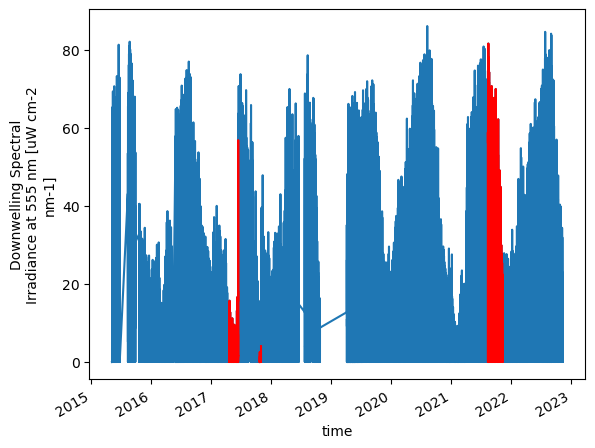

In [11]:
# Plot one SPKIR parameter with data with new annotations to be added shown in red
spkir.downwelling_irradiance_555.squeeze().plot()
spkir.downwelling_irradiance_555.sel(time=slice("2021-08-04T15:00:00", "2021-11-11T19:30:00")).plot(c='r')
spkir.downwelling_irradiance_555.sel(time=slice("2017-04-23T00:00:00", "2017-06-15T15:45:00")).plot(c='r')
spkir.downwelling_irradiance_555.sel(time=slice("2017-10-24T00:00:00", "2017-11-01T13:00:00")).plot(c='r')